<center><font size=10>Artificial Intelligence and Machine Learning</center></font>
<center><b><font size=6>Model Deployment: Superkart SProduct Sales Prediction  </font></b></center>

---
## **Problem Statement**

### Business Context

A sales forecast is a prediction of future sales revenue based on historical data, industry trends, and the status of the current sales pipeline. Businesses use the sales forecast to estimate weekly, monthly, quarterly, and annual sales totals. A company needs to make an accurate sales forecast as it adds value across an organization and helps the different verticals to chalk out their future course of action.

Forecasting helps an organization plan its sales operations by region and provides valuable insights to the supply chain team regarding the procurement of goods and materials. An accurate sales forecast process has many benefits which include improved decision-making about the future and reduction of sales pipeline and forecast risks. Moreover, it helps to reduce the time spent in planning territory coverage and establish benchmarks that can be used to assess trends in the future.

### Objective

SuperKart is a retail chain operating supermarkets and food marts across various tier cities, offering a wide range of products. To optimize its inventory management and make informed decisions around regional sales strategies, SuperKart wants to accurately forecast the sales revenue of its outlets for the upcoming quarter.

To operationalize these insights at scale, the company has partnered with a data science firm—not just to build a predictive model based on historical sales data, but to develop and deploy a robust forecasting solution that can be integrated into SuperKart’s decision-making systems and used across its network of stores.

### Data Description

The data contains the different attributes of the various products and stores.The detailed data dictionary is given below.

- **Product_Id** - unique identifier of each product, each identifier having two letters at the beginning followed by a number.
- **Product_Weight** - weight of each product
- **Product_Sugar_Content** - sugar content of each product like low sugar, regular and no sugar
- **Product_Allocated_Area** - ratio of the allocated display area of each product to the total display area of all the products in a store
- **Product_Type** - broad category for each product like meat, snack foods, hard drinks, dairy, canned, soft drinks, health and hygiene, baking goods, bread, breakfast, frozen foods, fruits and vegetables, household, seafood, starchy foods, others
- **Product_MRP** - maximum retail price of each product
- **Store_Id** - unique identifier of each store
- **Store_Establishment_Year** - year in which the store was established
- **Store_Size** - size of the store depending on sq. feet like high, medium and low
- **Store_Location_City_Type** - type of city in which the store is located like Tier 1, Tier 2 and Tier 3. Tier 1 consists of cities where the standard of living is comparatively higher than its Tier 2 and Tier 3 counterparts.
- **Store_Type** - type of store depending on the products that are being sold there like Departmental Store, Supermarket Type 1, Supermarket Type 2 and Food Mart
- **Product_Store_Sales_Total** - total revenue generated by the sale of that particular product in that particular store


---
## SuperKart Project Repository Structure
```mk
superkart_project/
│
├── superkart-api/
│   ├── Dockerfile
│   └── deployment_files/
│       ├── app.py
│       ├── feature_engineering.py
│       ├── requirements.txt
│       ├── superkart_sales_forecasting_model_v1_0.joblib
│       ├── model_input_columns.json
│       └── engineered_model_columns.json
│
└── superkart-frontend/
    ├── Dockerfile
    ├── streamlit_app.py
    ├── requirements.txt
    └── model_metrics.json    


---
## **Installing and Importing the necessary libraries**

In [1]:
#Installing the libraries with the specified versions
# !pip install numpy==2.0.2 pandas==2.2.2 scikit-learn==1.6.1 matplotlib==3.10.0 seaborn==0.13.2 joblib==1.4.2 xgboost==2.1.4 requests==2.32.4 huggingface_hub==0.34.0 -q

In [2]:
# Core libraries
import pandas as pd
import numpy as np

# Visualisation
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import sweetviz as sv # For EDA
import math
from matplotlib.pyplot import axes
from IPython.display import HTML

# Preprocessing and modelling
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from datetime import datetime

# Models
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor 
from xgboost import XGBRegressor


# Metrics
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)

# Serialization
import joblib
import json

# os related functionalities
import os
from pathlib import Path

# API request
import requests

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi


# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)


# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid")


---
## **Loading the dataset**

In [3]:
# loasding the dataset

df = pd.read_csv("SuperKart.csv")

print(f"shape of the dataset: {df.shape}")
print(f"Number of rows: {df.shape[0]}, Number of columns: {df.shape[1]}")

print("\n------------------------------\n")

display(df.head())

shape of the dataset: (8763, 12)
Number of rows: 8763, Number of columns: 12

------------------------------



,Product_Id,Product_Weight,Product_Sugar_Content,Product_Allocated_Area,Product_Type,Product_MRP,Store_Id,Store_Establishment_Year,Store_Size,Store_Location_City_Type,Store_Type,Product_Store_Sales_Total
0,FD6114,12.66,Low Sugar,0.027,Frozen Foods,117.08,OUT004,2009,Medium,Tier 2,Supermarket Type2,2842.40
1,FD7839,16.54,Low Sugar,0.144,Dairy,171.43,OUT003,1999,Medium,Tier 1,Departmental Store,4830.02
2,FD5075,14.28,Regular,0.031,Canned,162.08,OUT001,1987,High,Tier 2,Supermarket Type1,4130.16
3,FD8233,12.10,Low Sugar,0.112,Baking Goods,186.31,OUT001,1987,High,Tier 2,Supermarket Type1,4132.18
4,NC1180,9.57,No Sugar,0.010,Health and Hygiene,123.67,OUT002,1998,Small,Tier 3,Food Mart,2279.36


---
## **Data Overview**

In [4]:
kart = df.copy() # creating a copy of the original dataset to work with

print("\n------------------------------\n")

print("Data types of each column:")
print(kart.info() )

print("\n------------------------------\n")

# Statistical summary of the dataset
print("Summary statistics:")
kart.describe().T



------------------------------

Data types of each column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8763 entries, 0 to 8762
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Product_Id                 8763 non-null   object 
 1   Product_Weight             8763 non-null   float64
 2   Product_Sugar_Content      8763 non-null   object 
 3   Product_Allocated_Area     8763 non-null   float64
 4   Product_Type               8763 non-null   object 
 5   Product_MRP                8763 non-null   float64
 6   Store_Id                   8763 non-null   object 
 7   Store_Establishment_Year   8763 non-null   int64  
 8   Store_Size                 8763 non-null   object 
 9   Store_Location_City_Type   8763 non-null   object 
 10  Store_Type                 8763 non-null   object 
 11  Product_Store_Sales_Total  8763 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory us

,count,mean,std,min,25%,50%,75%,max
Product_Weight,8763.0,12.653792,2.217320,4.000,11.150,12.660,14.180,22.000
Product_Allocated_Area,8763.0,0.068786,0.048204,0.004,0.031,0.056,0.096,0.298
Product_MRP,8763.0,147.032539,30.694110,31.000,126.160,146.740,167.585,266.000
Store_Establishment_Year,8763.0,2002.032751,8.388381,1987.000,1998.000,2009.000,2009.000,2009.000
Product_Store_Sales_Total,8763.0,3464.003640,1065.630494,33.000,2761.715,3452.340,4145.165,8000.000


**Key Insights from Data Overview**

- The dataset contains a balanced mix of **numeric features** (e.g., **`Product_Weight`**, **`Product_MRP`**, **`Allocated_Area`**, **`Store_Establishment_Year`**) and **categorical variables** (e.g., **`Product_Type`**, **`Store_Type`**, **`City_Tier`**), confirming the need for a pipeline that handles **encoding + scaling + feature engineering**—fully aligned with the model‑deployment objective.

- All columns have **complete non‑null values (8763 each)** and no duplicated rows, meaning no imputation is required and the forecasting pipeline could focus on **transformations and model learning** rather than data cleaning.

- The presence of **identifier fields** like **`Product_Id`** and **`Store_Id`** (object types) reinforces the importance of excluding them from model training.

- Since the target variable `Product_Store_Sales_Total` is continuous, this is a regression problem.

---

**Key Statistical Insights**

- **Product Weight** shows a tight distribution (mean **12.65kg**, std **2.22**) with a wide sales range, indicating that heavier products tend to be positioned as higher‑value items—supporting earlier findings that weight strongly influences revenue.  
- **Product MRP** has a substantial spread (min **31**, max **266**, mean **147**), confirming strong price variation across SKUs and reinforcing its role as the **strongest sales driver**.  
- **Store Establishment Year** is heavily skewed toward newer stores (75% at **2009**), suggesting that most outlets are modern formats—important when interpreting store‑level performance differences.  
- **Total Store Sales** shows high variability (mean **3464**, std **1065**), indicating significant performance differences across stores, which aligns with the objective of forecasting outlet‑level sales to optimize inventory and regional planning.


---
##  **Exploratory Data Analysis (EDA)**

In [5]:
# Standardise column names by stripping whitespace from the headers  

kart.columns = [c.strip() for c in kart.columns]
kart.columns

Index(['Product_Id', 'Product_Weight', 'Product_Sugar_Content',
       'Product_Allocated_Area', 'Product_Type', 'Product_MRP', 'Store_Id',
       'Store_Establishment_Year', 'Store_Size', 'Store_Location_City_Type',
       'Store_Type', 'Product_Store_Sales_Total'],
      dtype='object')

### EDA with Sweetviz using the target variable

                                             |          | [  0%]   00:00 -> (? left)

Report kart_Report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.



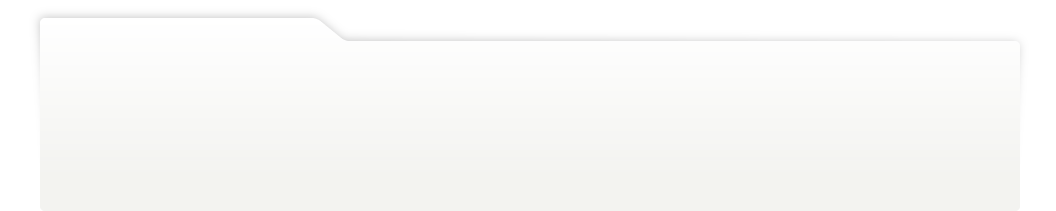
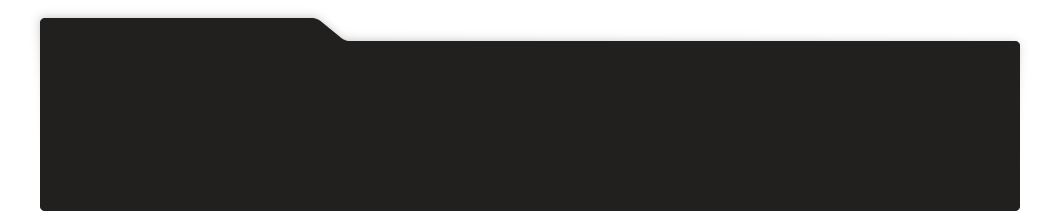
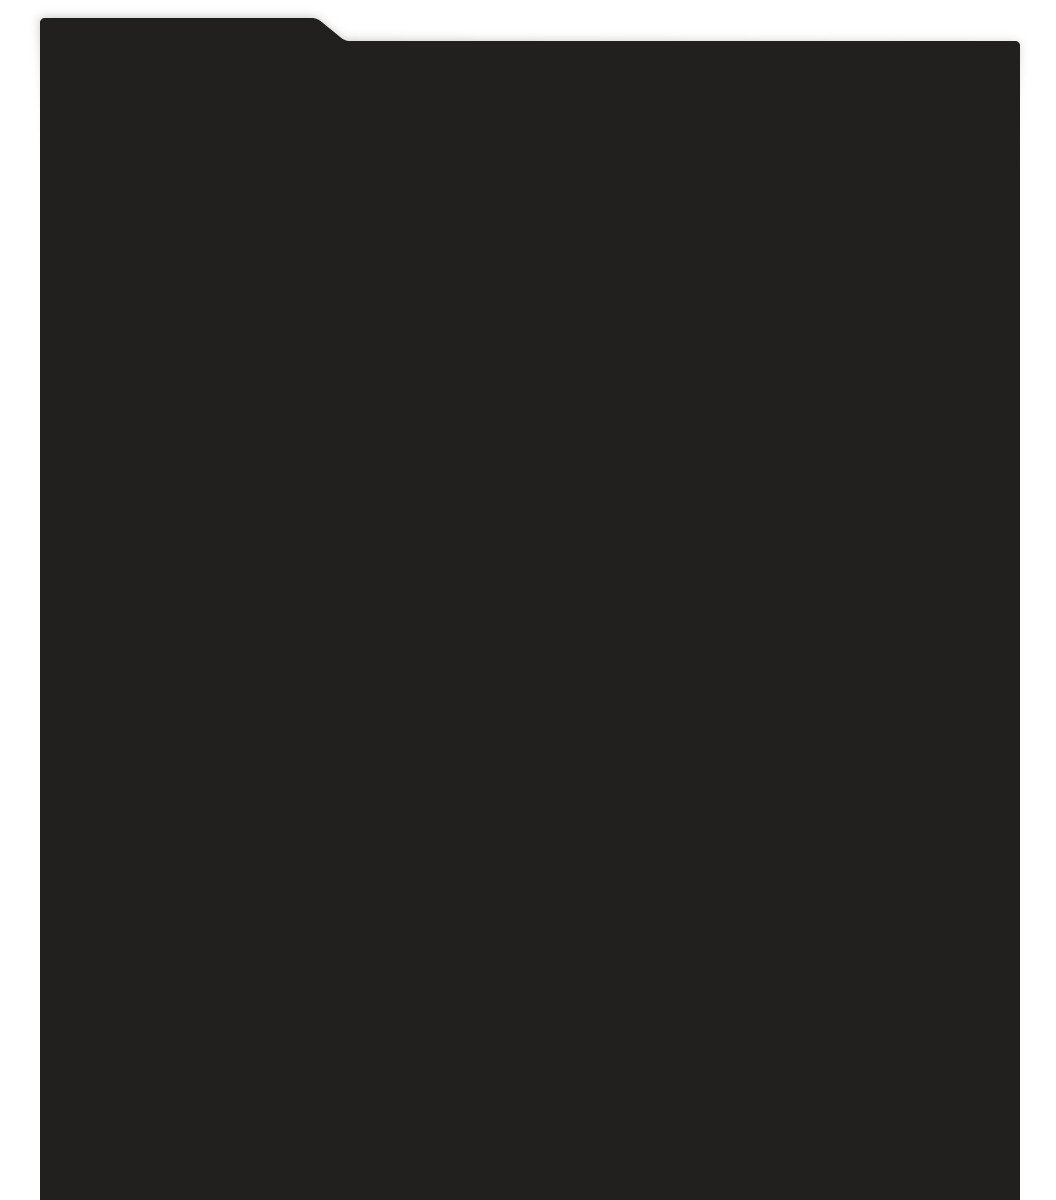
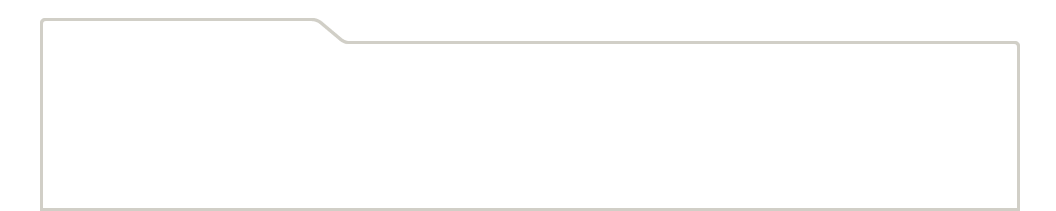
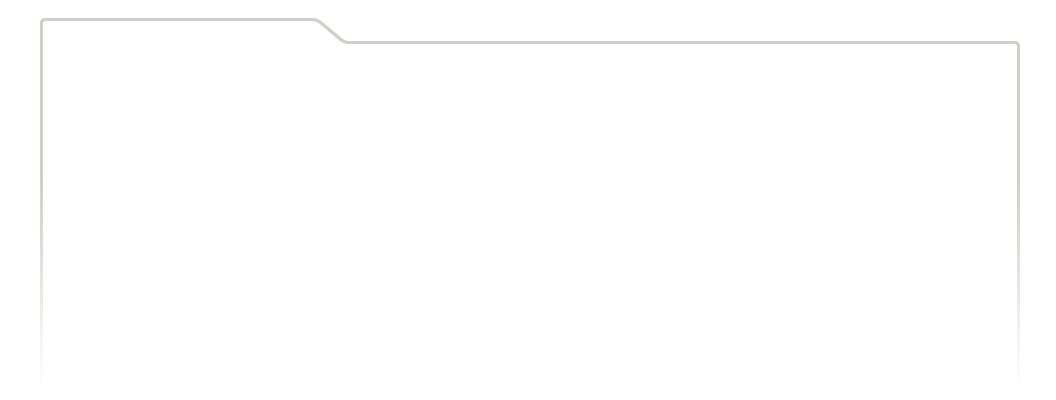
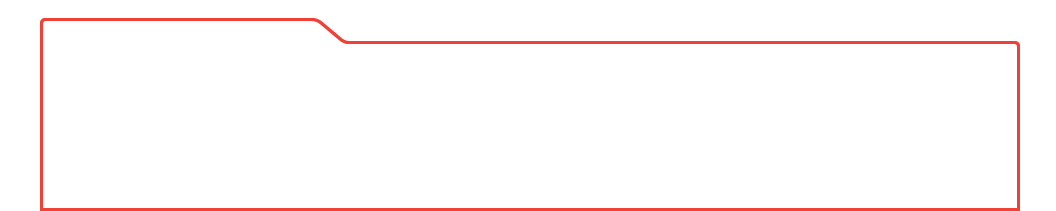
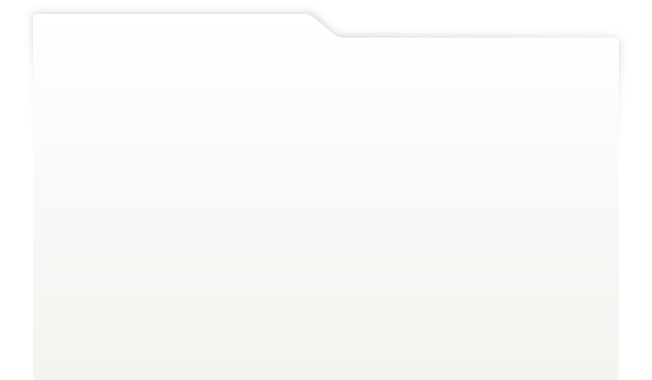
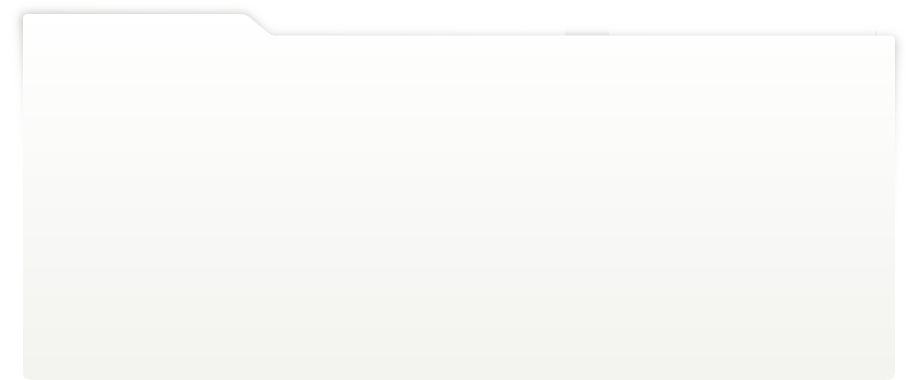
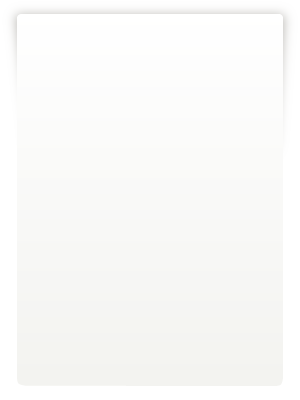
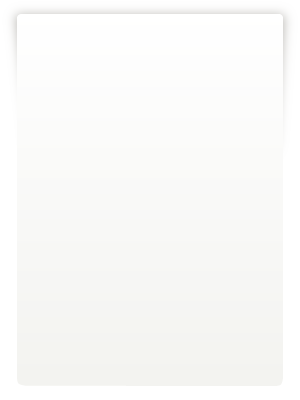
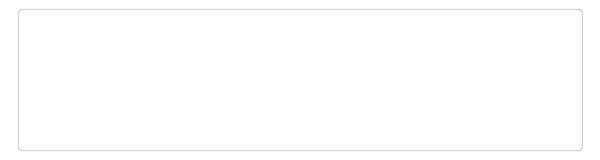
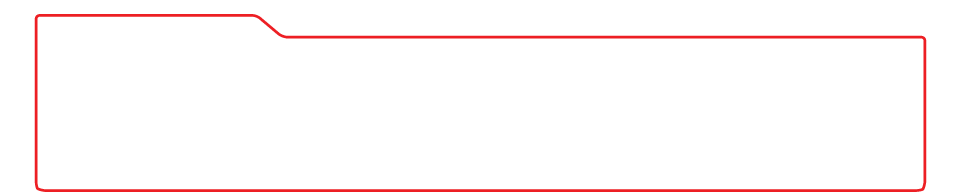
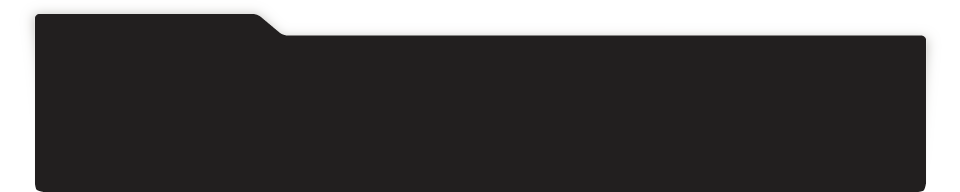
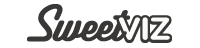
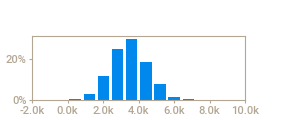
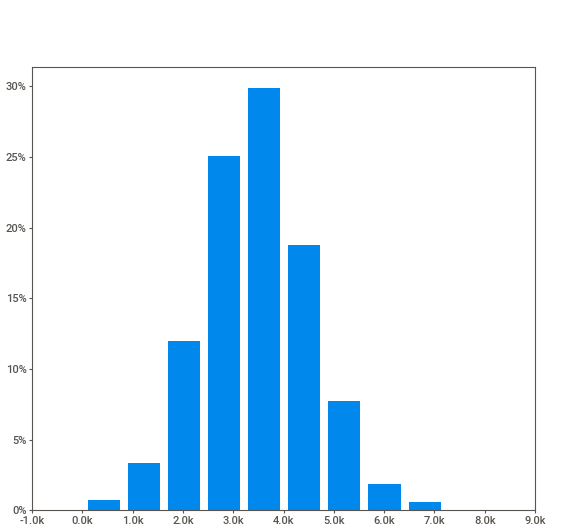
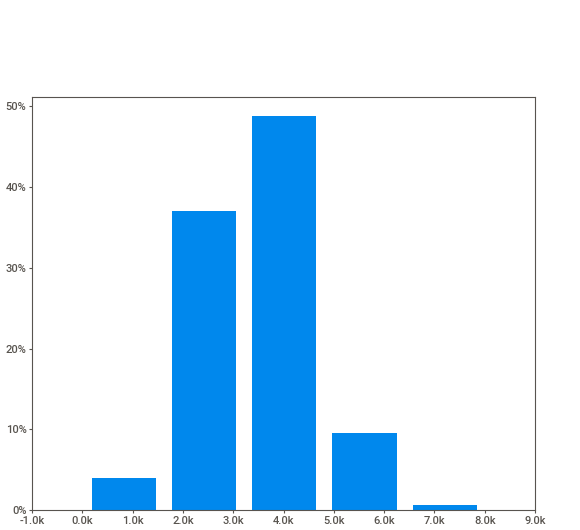
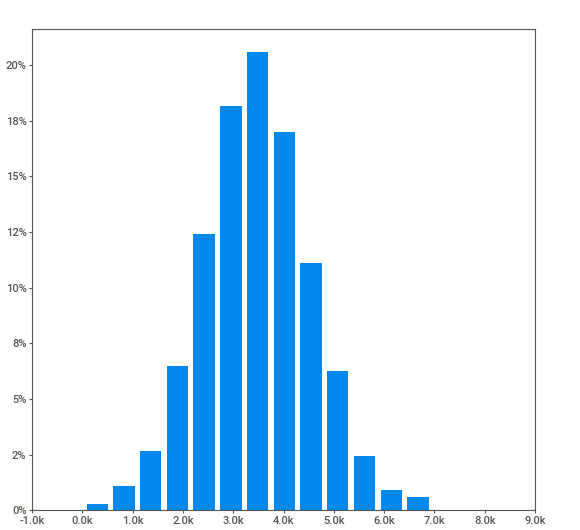
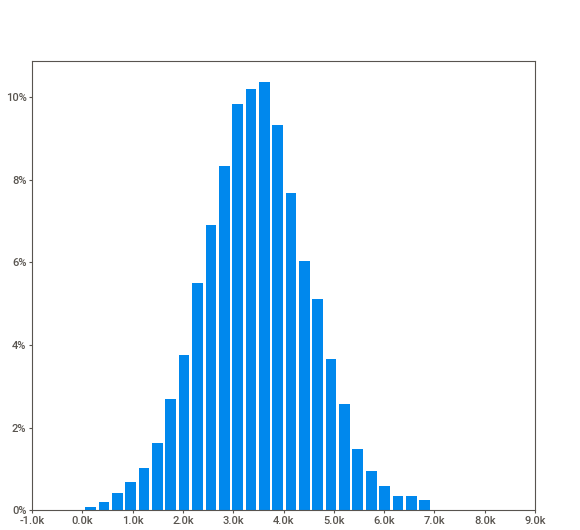
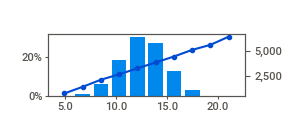
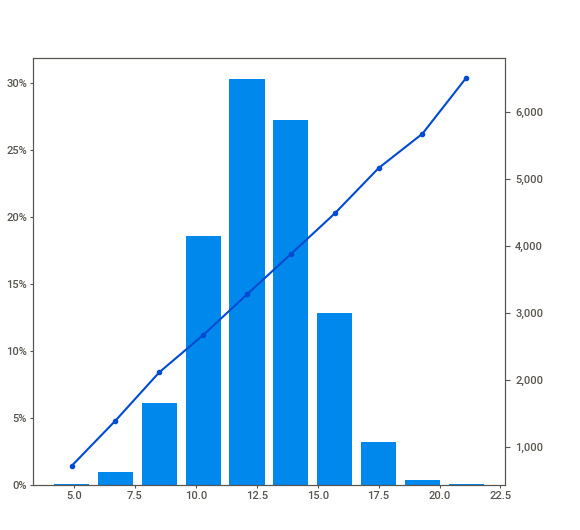
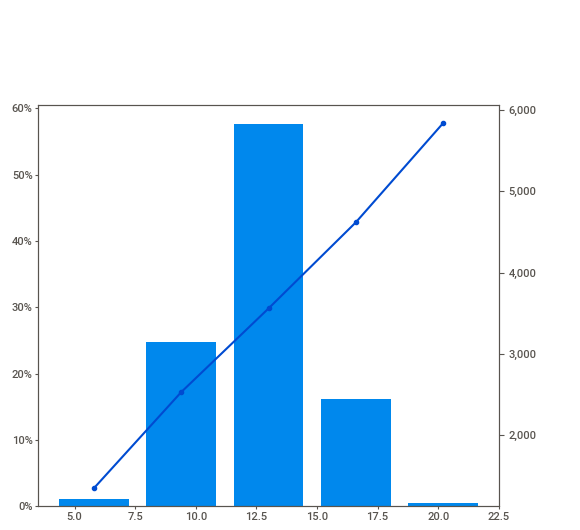
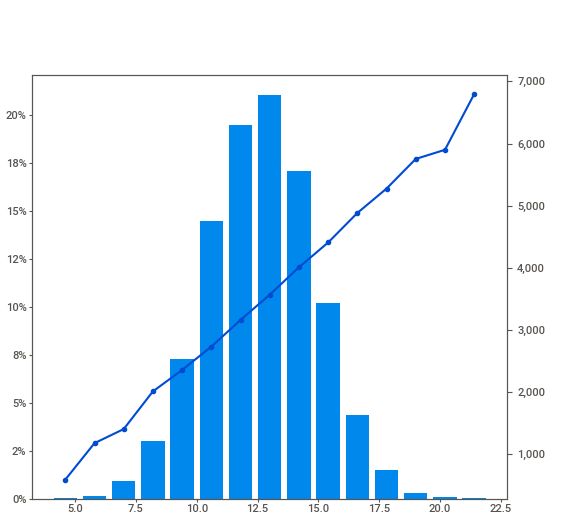
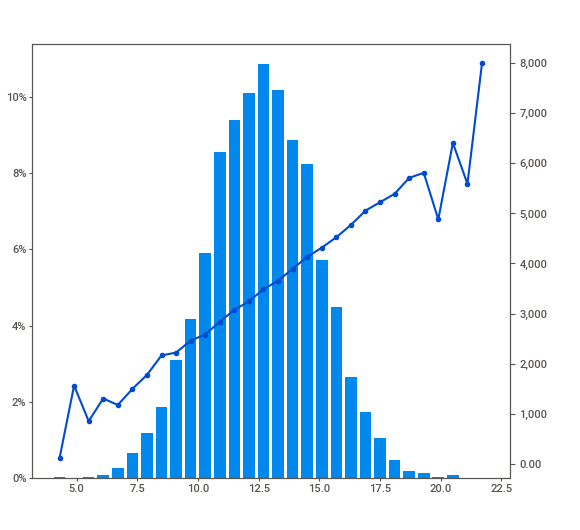
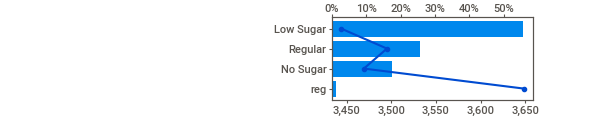
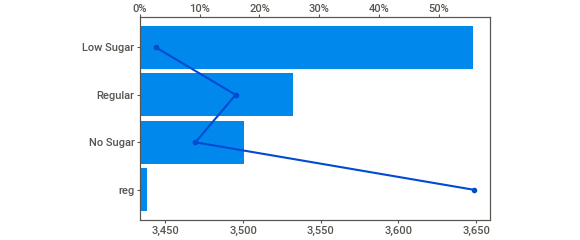
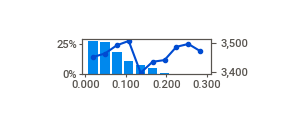
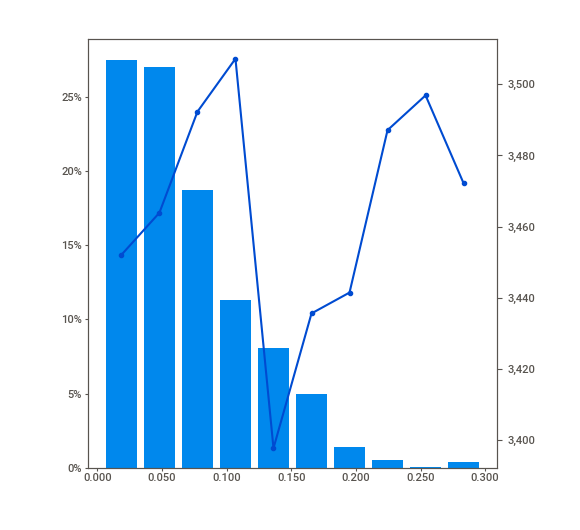
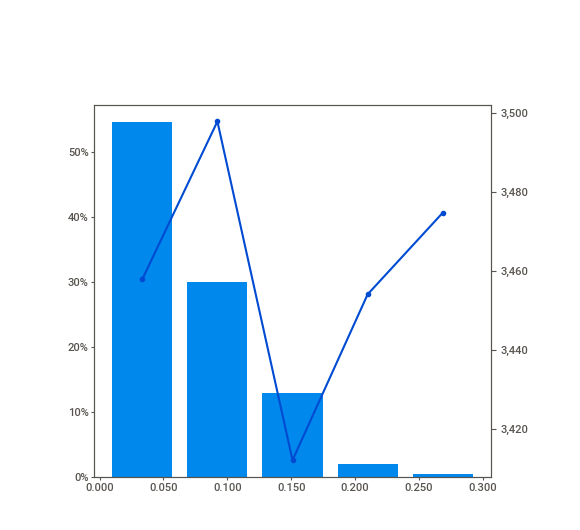
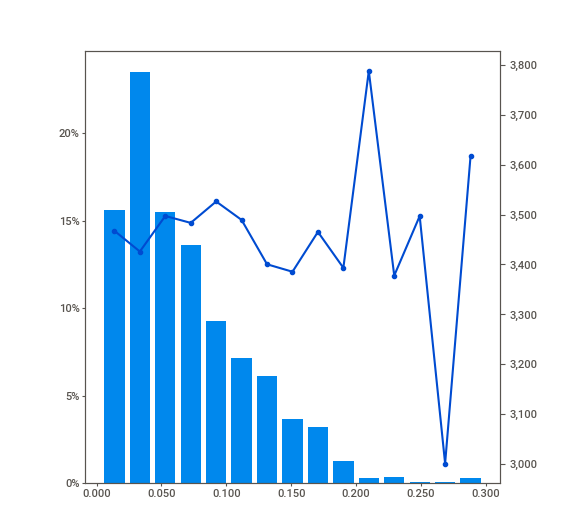
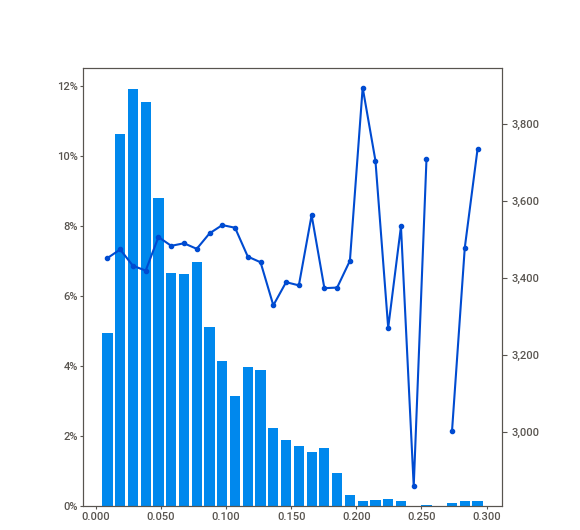
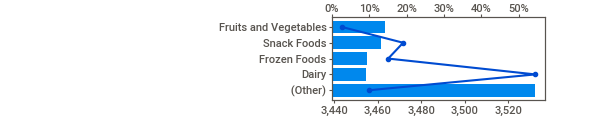
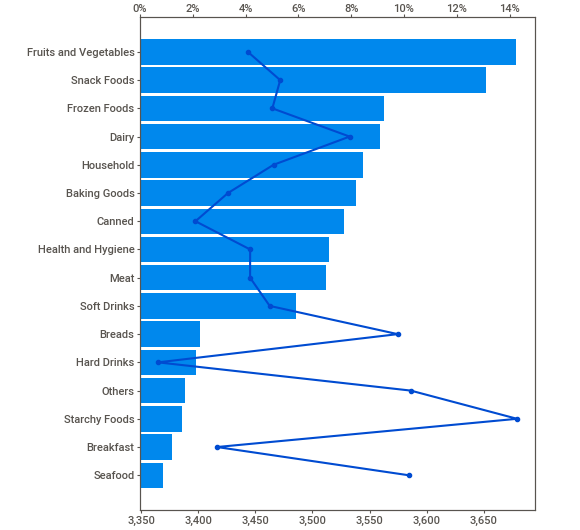
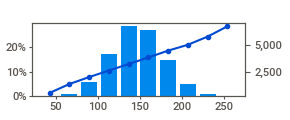
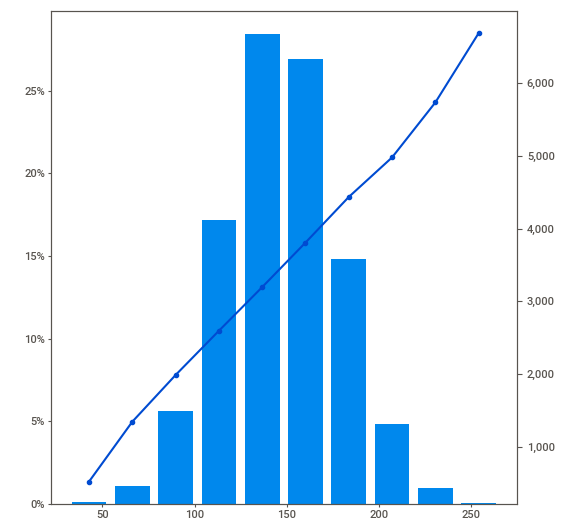
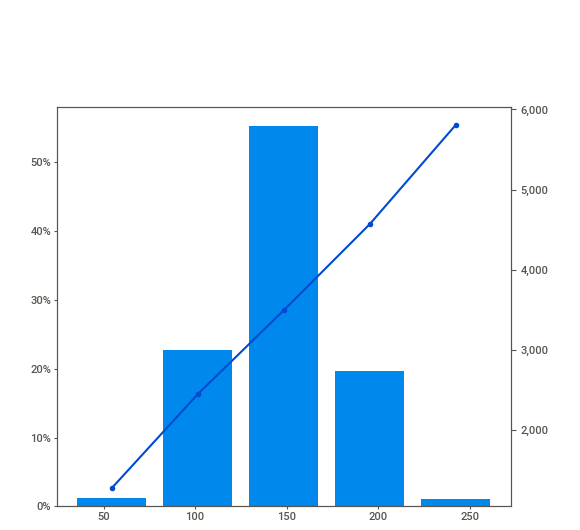
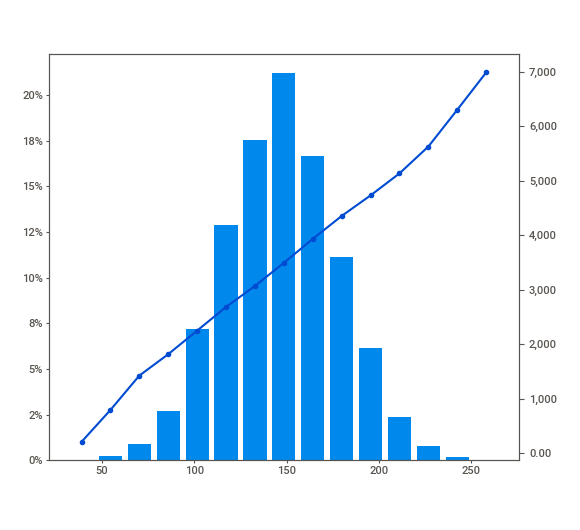
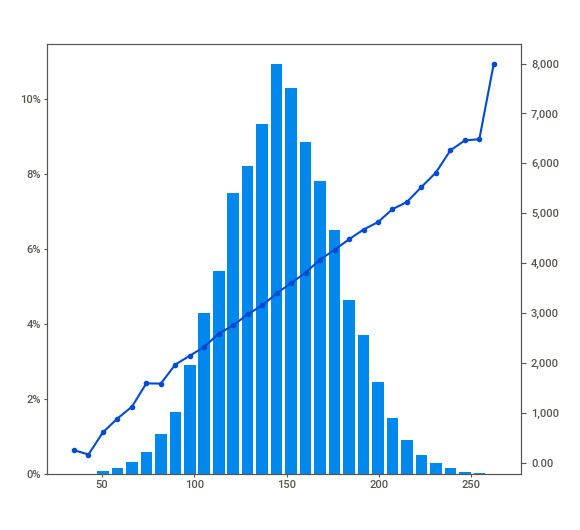
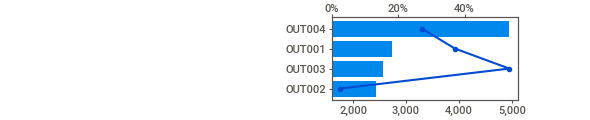
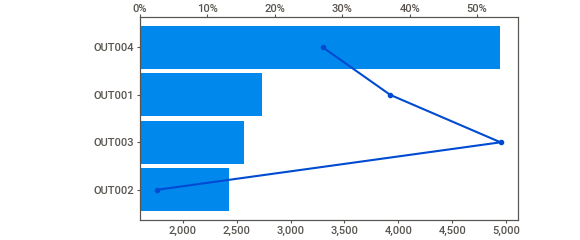
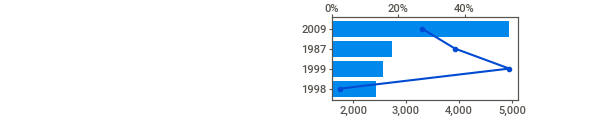
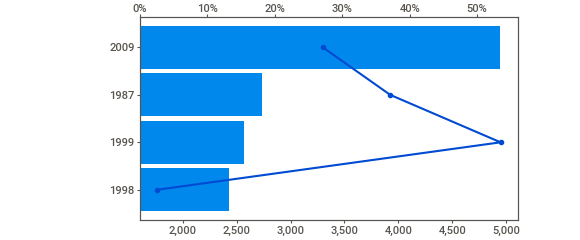
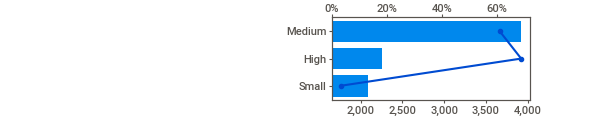
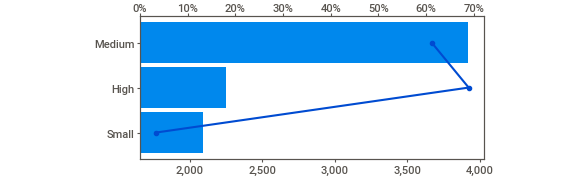
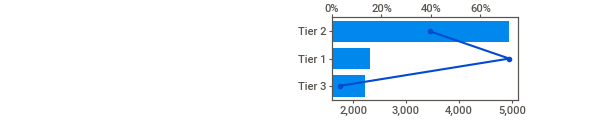
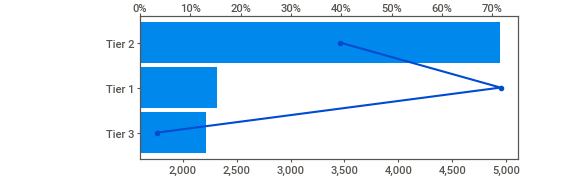
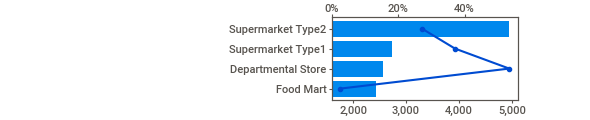
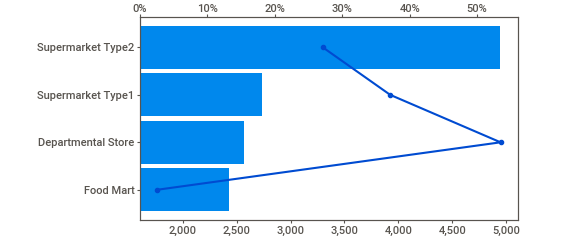
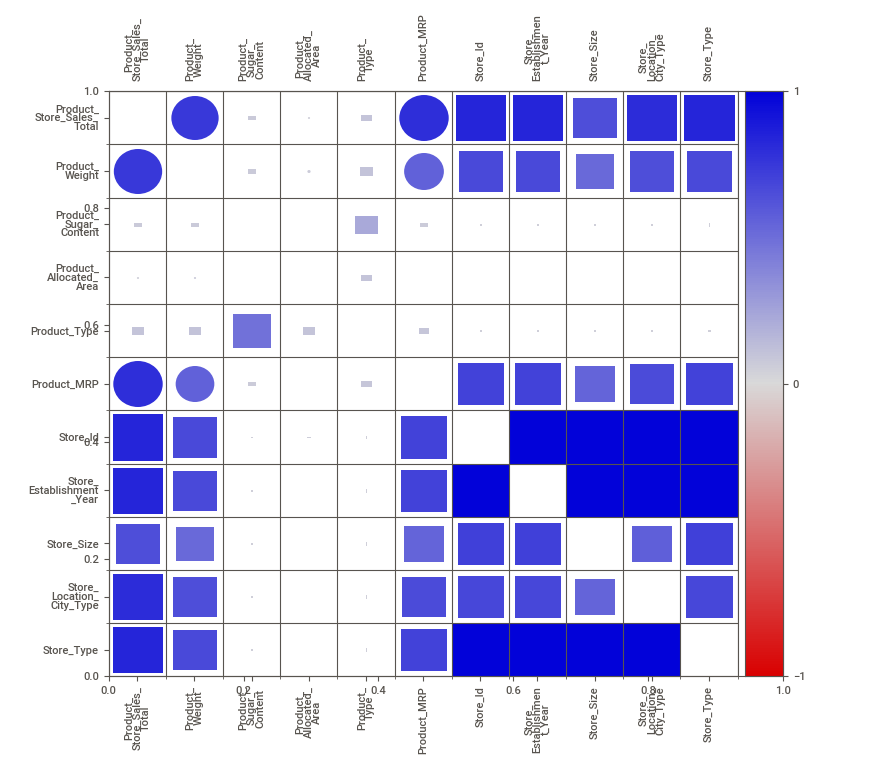
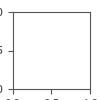

In [6]:
# Generate a Sweetviz report for the dataset with the target variable specified

target_col = "Product_Store_Sales_Total"

report = sv.analyze(
    kart,
    target_feat=target_col
)

# Generate HTML report
report.show_html("kart_Report.html")

# Display inline in notebook
report.show_notebook()

#### Summary of Key EDA Findings from Profiling Report ([Appendix A](kart_Report.html))


| Area                  | Finding                                                                | Outcome                                                       |
| --------------------- | ---------------------------------------------------------------------- | ------------------------------------------------------------- |
| Dataset Quality       | No missing values identified                                           | Dataset ready for analysis without imputation                 |
| Duplicate Records     | No duplicate records found                                             | No duplicate treatment required                               |
| Target Variable       | Sales distribution positively skewed with some high-value observations | Considered target transformation to improve model performance |
| Product MRP           | Strongest predictor of sales                                           | Retained as key feature                                       |
| Store Characteristics | Store Type, Location and Size show strong association with sales       | Important business drivers                                    |
| Product Type          | Sales vary across product categories                                   | Useful categorical predictor                                  |
| Product Weight        | Positive relationship with sales                                       | Retained for modeling                                         |
| Product Sugar Content | Weak relationship with sales                                           | Retained but lower predictive importance                      |
| Feature Relationships | Several meaningful associations with sales identified                  | Supports predictive modeling                                  |
| Feature Engineering   | Store Age will be derived from Establishment Year                              | Improved business interpretability                            |

**Recommended Models**

| Model                       | Purpose                             |
| --------------------------- | ----------------------------------- |
| Decision Tree Regressor     | Baseline tree model                 |
| Random Forest Regressor     | Robust bagging ensemble             |
| Gradient Boosting Regressor | Sequential boosting model           |
| AdaBoost Regressor          | Adaptive boosting benchmark         |
| XGBoost Regressor           | High-performance optimized boosting |


**Evaluation Metrics**

| Metric      | Purpose                          |
| ----------- | -------------------------------- |
| MAE         | Average prediction error         |
| RMSE        | Penalizes large errors           |
| R²          | Explained variance               |
| Adjusted R² | Penalizes unnecessary predictors |


### EDA Utility Function

In [7]:
# Custom EDA function to plot numeric distributions and categorical countplots in a grid format

def plot_numeric_and_categorical_eda(df, numeric_cols, categorical_cols):
    """
    Generates:
      1. Numeric Histograms + Boxplots (with median annotation + outlier count)
      2. Categorical Countplots (grid)
    """

    sns.set(style="whitegrid")

    # ============================================================
    # 1. NUMERIC DISTRIBUTIONS (Histogram + Boxplot + Outlier Count)
    # ============================================================
    n_cols = 2   # histogram + boxplot
    n_rows = len(numeric_cols)

    plt.figure(figsize=(14, n_rows * 4))
    plt.suptitle("Numeric Distributions (Histogram + Boxplot + Outlier Count)", fontsize=16, y=1.02)

    for i, col in enumerate(numeric_cols):
        median_val = df[col].median()

        # Histogram
        ax1 = plt.subplot(n_rows, n_cols, 2*i + 1)
        sns.histplot(df[col], kde=True, ax=ax1)
        ax1.axvline(median_val, color='red', linestyle='--', linewidth=1.5)
        ax1.text(median_val, ax1.get_ylim()[1]*0.9,
                 f"Median = {median_val:.2f}",
                 color='red', ha='center', fontsize=9)
        ax1.set_title(f"Distribution of {col}")

        # Boxplot
        ax2 = plt.subplot(n_rows, n_cols, 2*i + 2)
        sns.boxplot(x=df[col], ax=ax2)
        ax2.axvline(median_val, color='red', linestyle='--', linewidth=1.5)
        ax2.text(median_val, ax2.get_ylim()[0],
                 f"{median_val:.2f}",
                 color='red', ha='center', va='bottom', fontsize=9)
        ax2.set_title(f"Boxplot of {col}")

        # ---- IQR Outlier Calculation ----
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outlier_count = df[(df[col] < lower) | (df[col] > upper)].shape[0]

        # ---- Add outlier count below boxplot ----
        ax2.text(
            0.5, -0.25,
            f"Outliers: {outlier_count}",
            ha="center", va="center",
            transform=ax2.transAxes,
            fontsize=10, color="red"
        )

    plt.tight_layout()
    plt.show()

    # ============================================================
    # 2. CATEGORICAL COUNTPLOTS (Grid)
    # ============================================================
    n_cols = 3
    n_rows = math.ceil(len(categorical_cols) / n_cols)

    plt.figure(figsize=(18, n_rows * 4))
    plt.suptitle("Categorical Variable Countplots", fontsize=16, y=1.02)

    for i, col in enumerate(categorical_cols, 1):
        ax = plt.subplot(n_rows, n_cols, i)

        order = df[col].value_counts().index
        counts = df[col].value_counts()
        total = len(df)

        sns.countplot(y=df[col], order=order, ax=ax)
        ax.set_title(f"Countplot of {col}")

        # ---- Add percentage labels ----
        for idx, value in enumerate(counts):
            pct = (value / total) * 100
            ax.annotate(
                f"{pct:.1f}%",
                xy=(value, idx),
                xytext=(5, 0),
                textcoords="offset points",
                va="center",
                fontsize=10
            )

    plt.tight_layout()
    plt.show()




In [8]:
# Custom EDA function to plot relationships between sales and numeric variables in a grid format


def plot_sales_relationships_n(
    df,
    numeric_cols,
    target_col,
    focus_cols=None,
    cols=3
):
    """
    Plots sales relationship with numerical variables.
    Uses regression lines to support modelling decisions.
    """

    sns.set(style="whitegrid")

    # Use focus columns if provided, otherwise use all numeric columns except target
    if focus_cols:
        plot_cols = focus_cols
    else:
        plot_cols = [col for col in numeric_cols if col != target_col]

    rows = math.ceil(len(plot_cols) / cols)

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(5 * cols, 3.8 * rows)
    )

    axes = axes.flatten()

    for ax, col in zip(axes, plot_cols):

        corr = df[[col, target_col]].corr().iloc[0, 1]

        sns.regplot(
            data=df,
            x=col,
            y=target_col,
            scatter_kws={"alpha": 1},
            line_kws={"color": "red"},
            ax=ax
        )


        ax.set_title(f"{col} vs Sales | r={corr:.2f}")
        ax.set_xlabel(col)
        ax.set_ylabel("Sales")

    # Hide unused axes
    for ax in axes[len(plot_cols):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()


In [9]:
#  Custom EDA function to plot relationships between sales and categorical variables in a grid format

def plot_sales_relationships_c(df, categorical_cols, target_col):
    """
    Categorical bivariate analysis:
    - Horizontal boxplot with mean annotation
    - Horizontal sales contribution %
    - 2 categorical variables per row
    """

    sns.set(style="whitegrid")

    total_sales = df[target_col].sum()
    rows = math.ceil(len(categorical_cols) / 2)

    fig, axes = plt.subplots(
        rows,
        4,
        figsize=(20, 4.5 * rows)
    )

    axes = axes.reshape(rows, 4)

    for idx, col in enumerate(categorical_cols):

        row = idx // 2
        start_col = 0 if idx % 2 == 0 else 2

        box_ax = axes[row, start_col]
        bar_ax = axes[row, start_col + 1]

        # Summary
        means = df.groupby(col)[target_col].mean().sort_values()
        sales_pct = (
            df.groupby(col)[target_col]
            .sum()
            .sort_values()
            / total_sales
            * 100
        )

        # Horizontal boxplot
        sns.boxplot(
            data=df,
            y=col,
            x=target_col,
            order=means.index,
            ax=box_ax
        )

        for pos, val in enumerate(means):
            box_ax.text(
                val,
                pos,
                f" {val:,.0f}",
                va="center",
                color="red",
                fontsize=8,
                fontweight="bold"
            )

        box_ax.set_title(f"{col} - Sales Distribution", fontsize=10)
        box_ax.set_xlabel("Sales")
        box_ax.set_ylabel("")

        # Horizontal contribution chart
        sns.barplot(
            x=sales_pct.values,
            y=sales_pct.index,
            ax=bar_ax
        )

        for pos, val in enumerate(sales_pct.values):
            bar_ax.text(
                val,
                pos,
                f" {val:.1f}%",
                va="center",
                fontsize=8
            )

        bar_ax.set_title(f"{col} - Sales Contribution", fontsize=10)
        bar_ax.set_xlabel("% Sales")
        bar_ax.set_ylabel("")

    # Hide unused axes
    used_axes = len(categorical_cols) * 2
    for ax in axes.flatten()[used_axes:]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

### Check Target Distribution

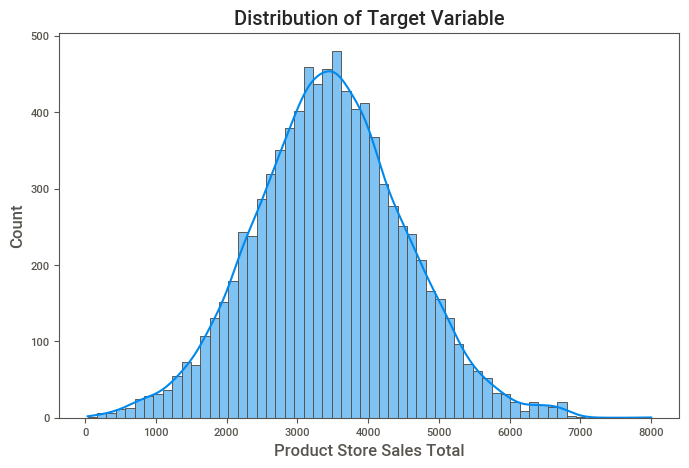

In [10]:
target_col = "Product_Store_Sales_Total"

plt.figure(figsize=(8, 5))

sns.histplot(
    kart[target_col],
    kde=True
)

plt.title("Distribution of Target Variable")
plt.xlabel("Product Store Sales Total")
plt.show()

**Target Variable Transformation Decision**

The target variable showed only mild skewness and remained close to a normal distribution. Tree‑based models do not require target normality and handle skewed values well. To preserve interpretability and maintain the natural business meaning of sales revenue, the original target values were kept without transformation.

### Univariate Analysis

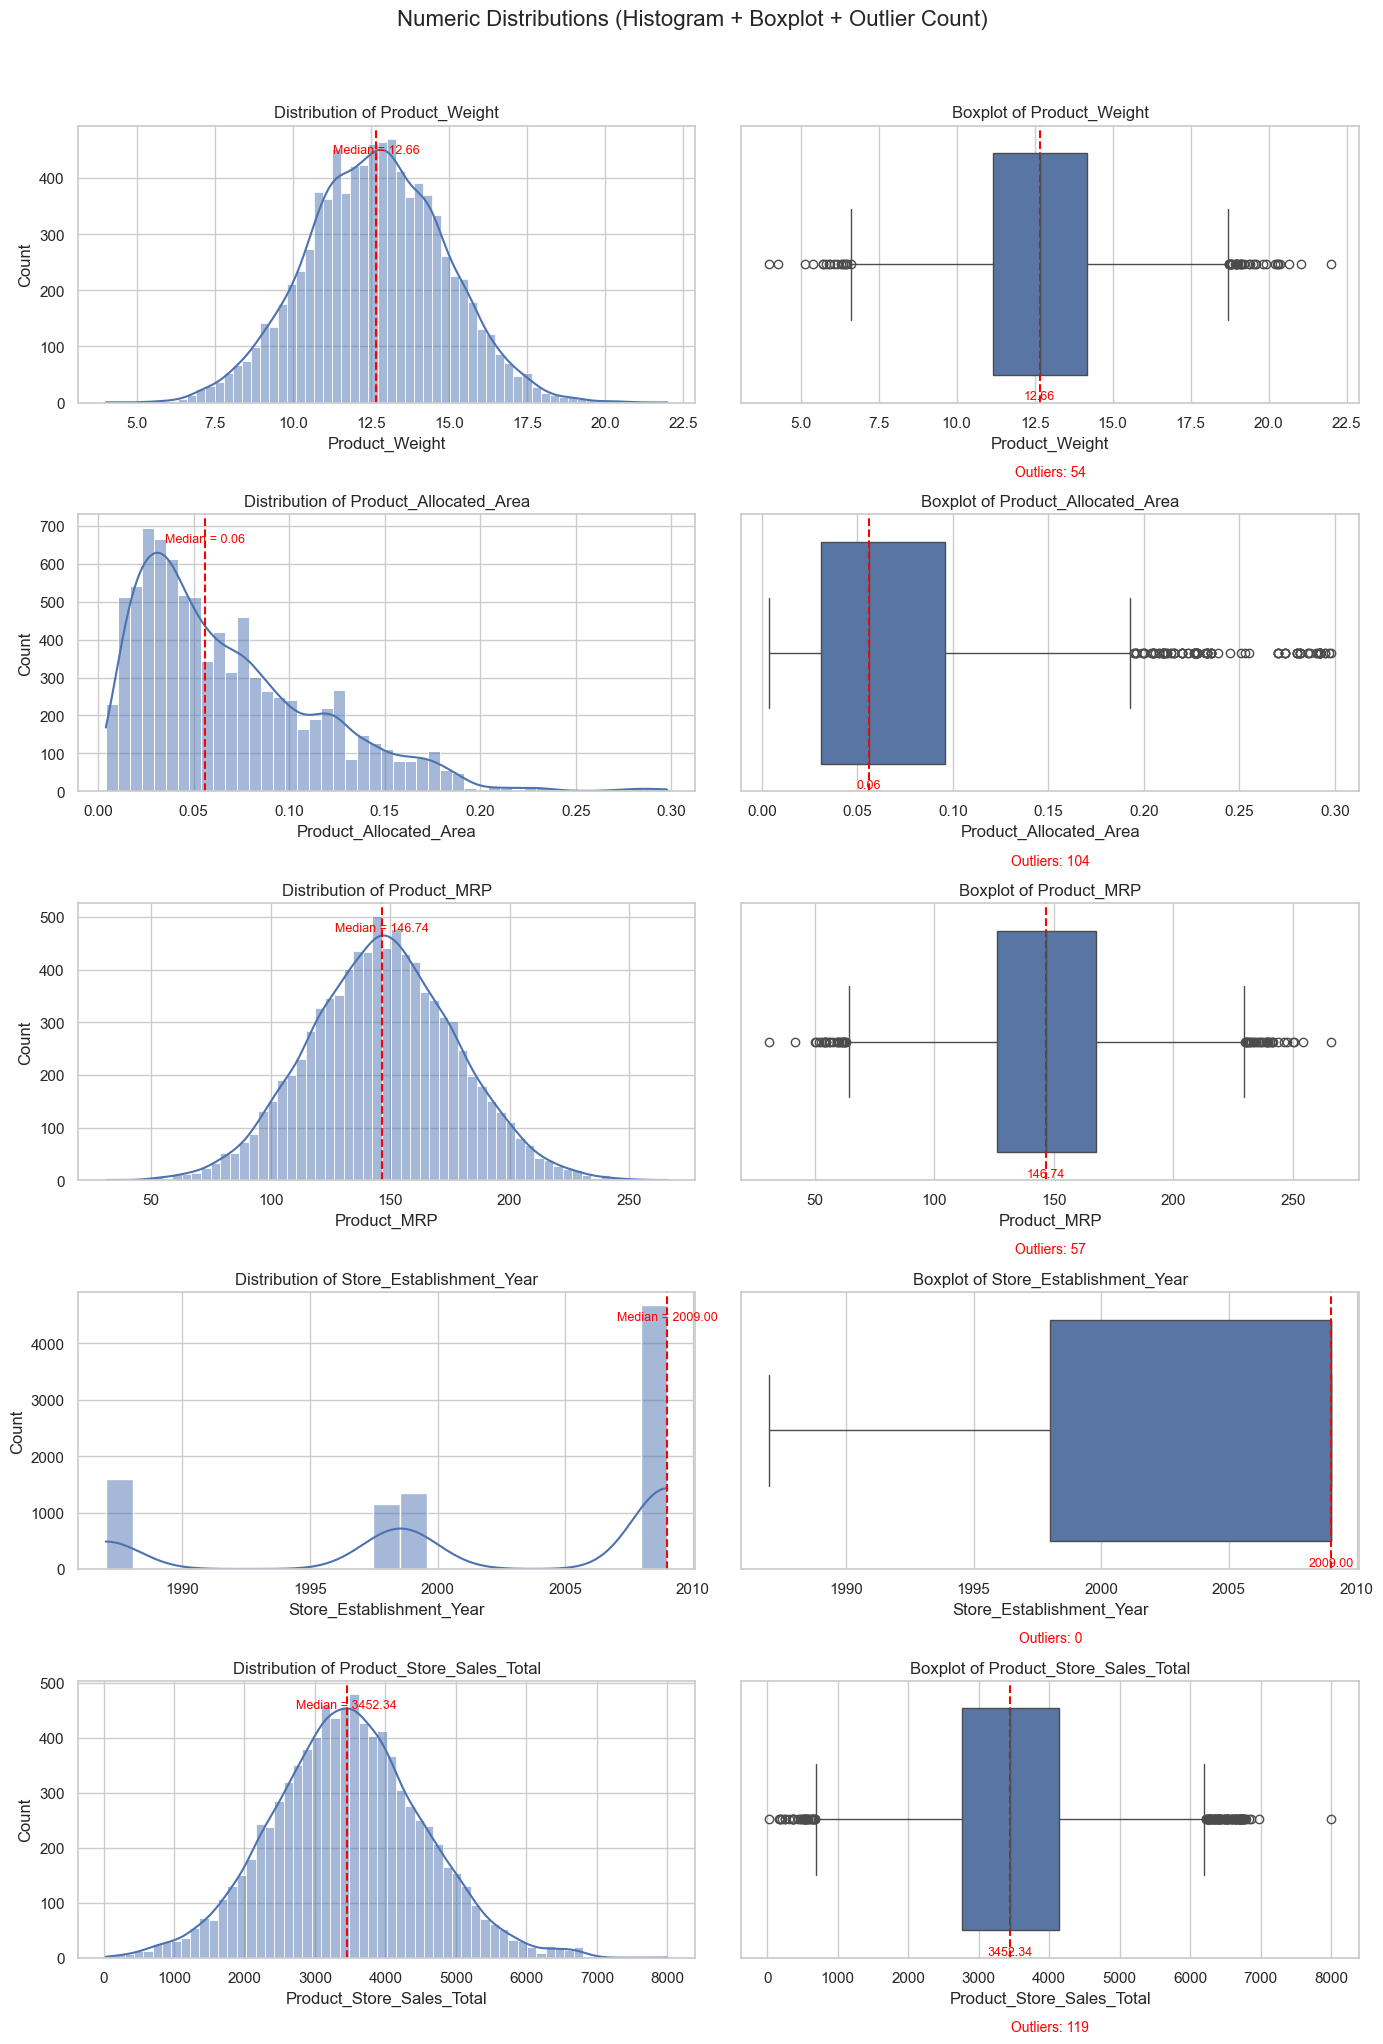

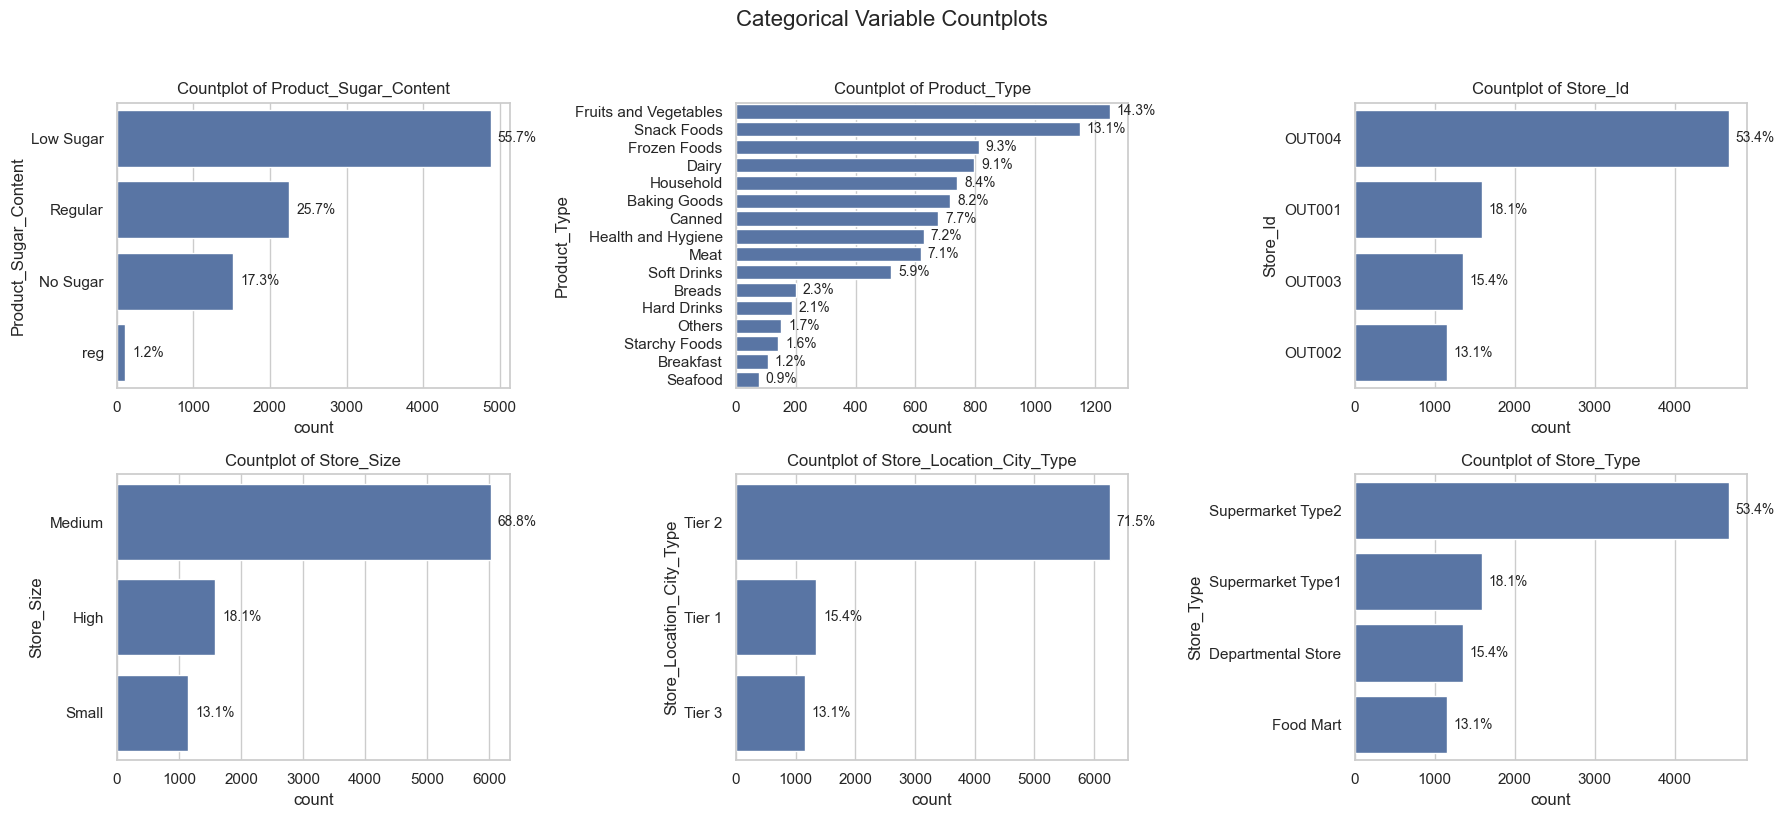

In [11]:
# Select numeric columns
numeric_cols = kart.select_dtypes(include=['int64', 'float64']).columns
# Categorical columns (excluding IDs)
categorical_cols = kart.select_dtypes(include='object').columns.drop(['Product_Id'])


# Call the EDA plotting function
plot_numeric_and_categorical_eda(kart, numeric_cols, categorical_cols)  


**Univariate Analysis Observations**

- **Product‑level numeric features show moderate skew and many outliers**, especially in *Product_Allocated_Area*, *Product_Weight*, and *Product_Store_Sales_Total*, indicating wide variability in product characteristics and sales performance.  
- **Store_Establishment_Year is clean with no outliers**, suggesting consistent store opening patterns and no extreme historical values.  
- **Categorical variables are highly imbalanced**, with dominant classes such as *Low Sugar*, *Fruits and Vegetables*, *Medium‑sized stores*, and *Tier 2 locations*, which may influence model learning.  
- **Store‑related categories (Store_Size, Store_Location_City_Type, Store_Type)** show strong concentration in a few classes, implying limited diversity in store profiles.  
- **Product_Type distribution is broad**, indicating a wide variety of product categories, but still dominated by a few high‑frequency groups.

### Bivariate Analysis

#### Correlation

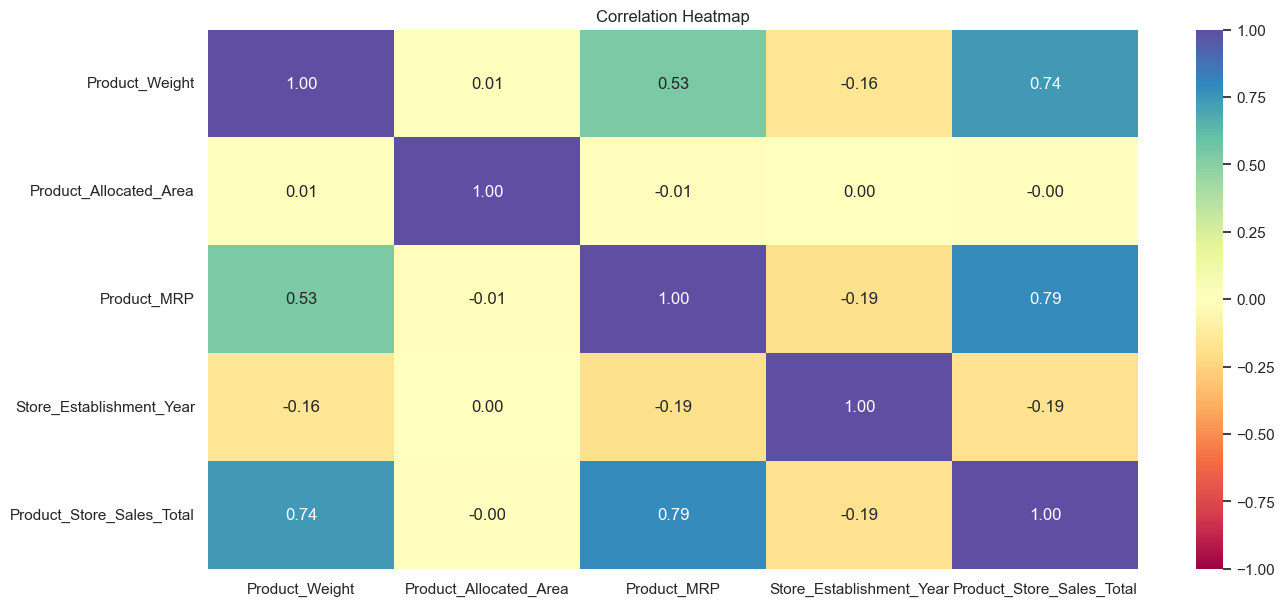

In [12]:
# Correlation heatmap for numeric variables

plt.figure(figsize=(15, 7))
sns.heatmap(df.corr(numeric_only = True), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.title("Correlation Heatmap")
plt.show()

**Correlation Analysis Insights**

- Product MRP has the strongest relationship with sales (r = 0.79), indicating that higher-priced products tend to generate higher revenue.
- Product Weight is also strongly correlated with sales (r = 0.74), making it another important predictor.
Store Establishment Year shows a weak negative relationship (r = -0.19), suggesting limited influence on sales.
Product Allocated Area has virtually no correlation (r ≈ 0.00), indicating minimal linear impact on sales.
Product Weight and Product MRP are moderately correlated (r = 0.53), which should be monitored for multicollinearity.

Next Steps
- Conduct detailed bivariate analysis for Product MRP and Product Weight.
Analyze categorical variables to identify additional sales drivers.
Check multicollinearity using VIF.
Proceed with feature engineering and model development.
Retain weakly correlated features initially, as tree-based models can capture non-linear relationships.

#### Distribution of our target variable i.e Product_Store_Sales_Total with numeric and categorical columns

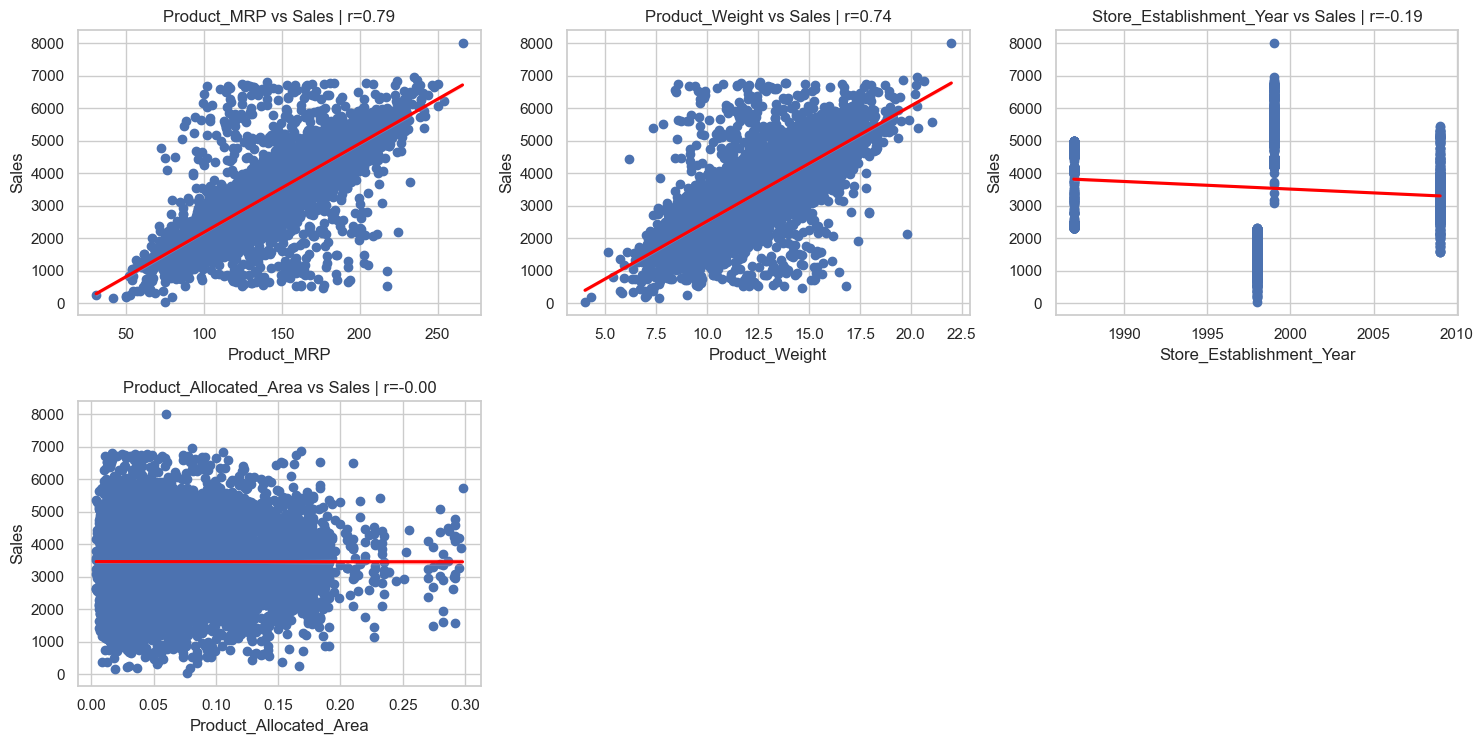

In [13]:
# plotting relationships between sales and numeric variables

target_col = "Product_Store_Sales_Total"

focus_numeric_cols = [
    "Product_MRP",
    "Product_Weight",
    "Store_Establishment_Year",
    "Product_Allocated_Area"
]

plot_sales_relationships_n(
    df=kart,
    numeric_cols=numeric_cols,
    target_col=target_col,
    focus_cols=focus_numeric_cols
)

**Numerical Bivariate Analysis Insights**

* **Product MRP** shows the strongest positive relationship with sales (**r = 0.79**), indicating that higher-priced products generally generate higher sales revenue. This confirms pricing as a key revenue driver.

* **Product Weight** also exhibits a strong positive correlation with sales (**r = 0.74**), suggesting that larger or heavier products tend to contribute more revenue.

* **Store Establishment Year** has a weak negative relationship with sales (**r = -0.19**), indicating that store age has limited influence on sales performance and is unlikely to be a primary predictor.

* **Product Allocated Area** shows virtually no linear relationship with sales (**r ≈ 0.00**), suggesting minimal direct impact on revenue. However, it should be retained initially as tree-based models may capture non-linear effects not visible through correlation analysis.

**Modelling Implication**

The analysis identifies **Product MRP** and **Product Weight** as the most influential numerical predictors and strong candidates for feature importance in the final model, while **Store Establishment Year** and **Product Allocated Area** require further evaluation through feature importance and model performance rather than correlation alone.


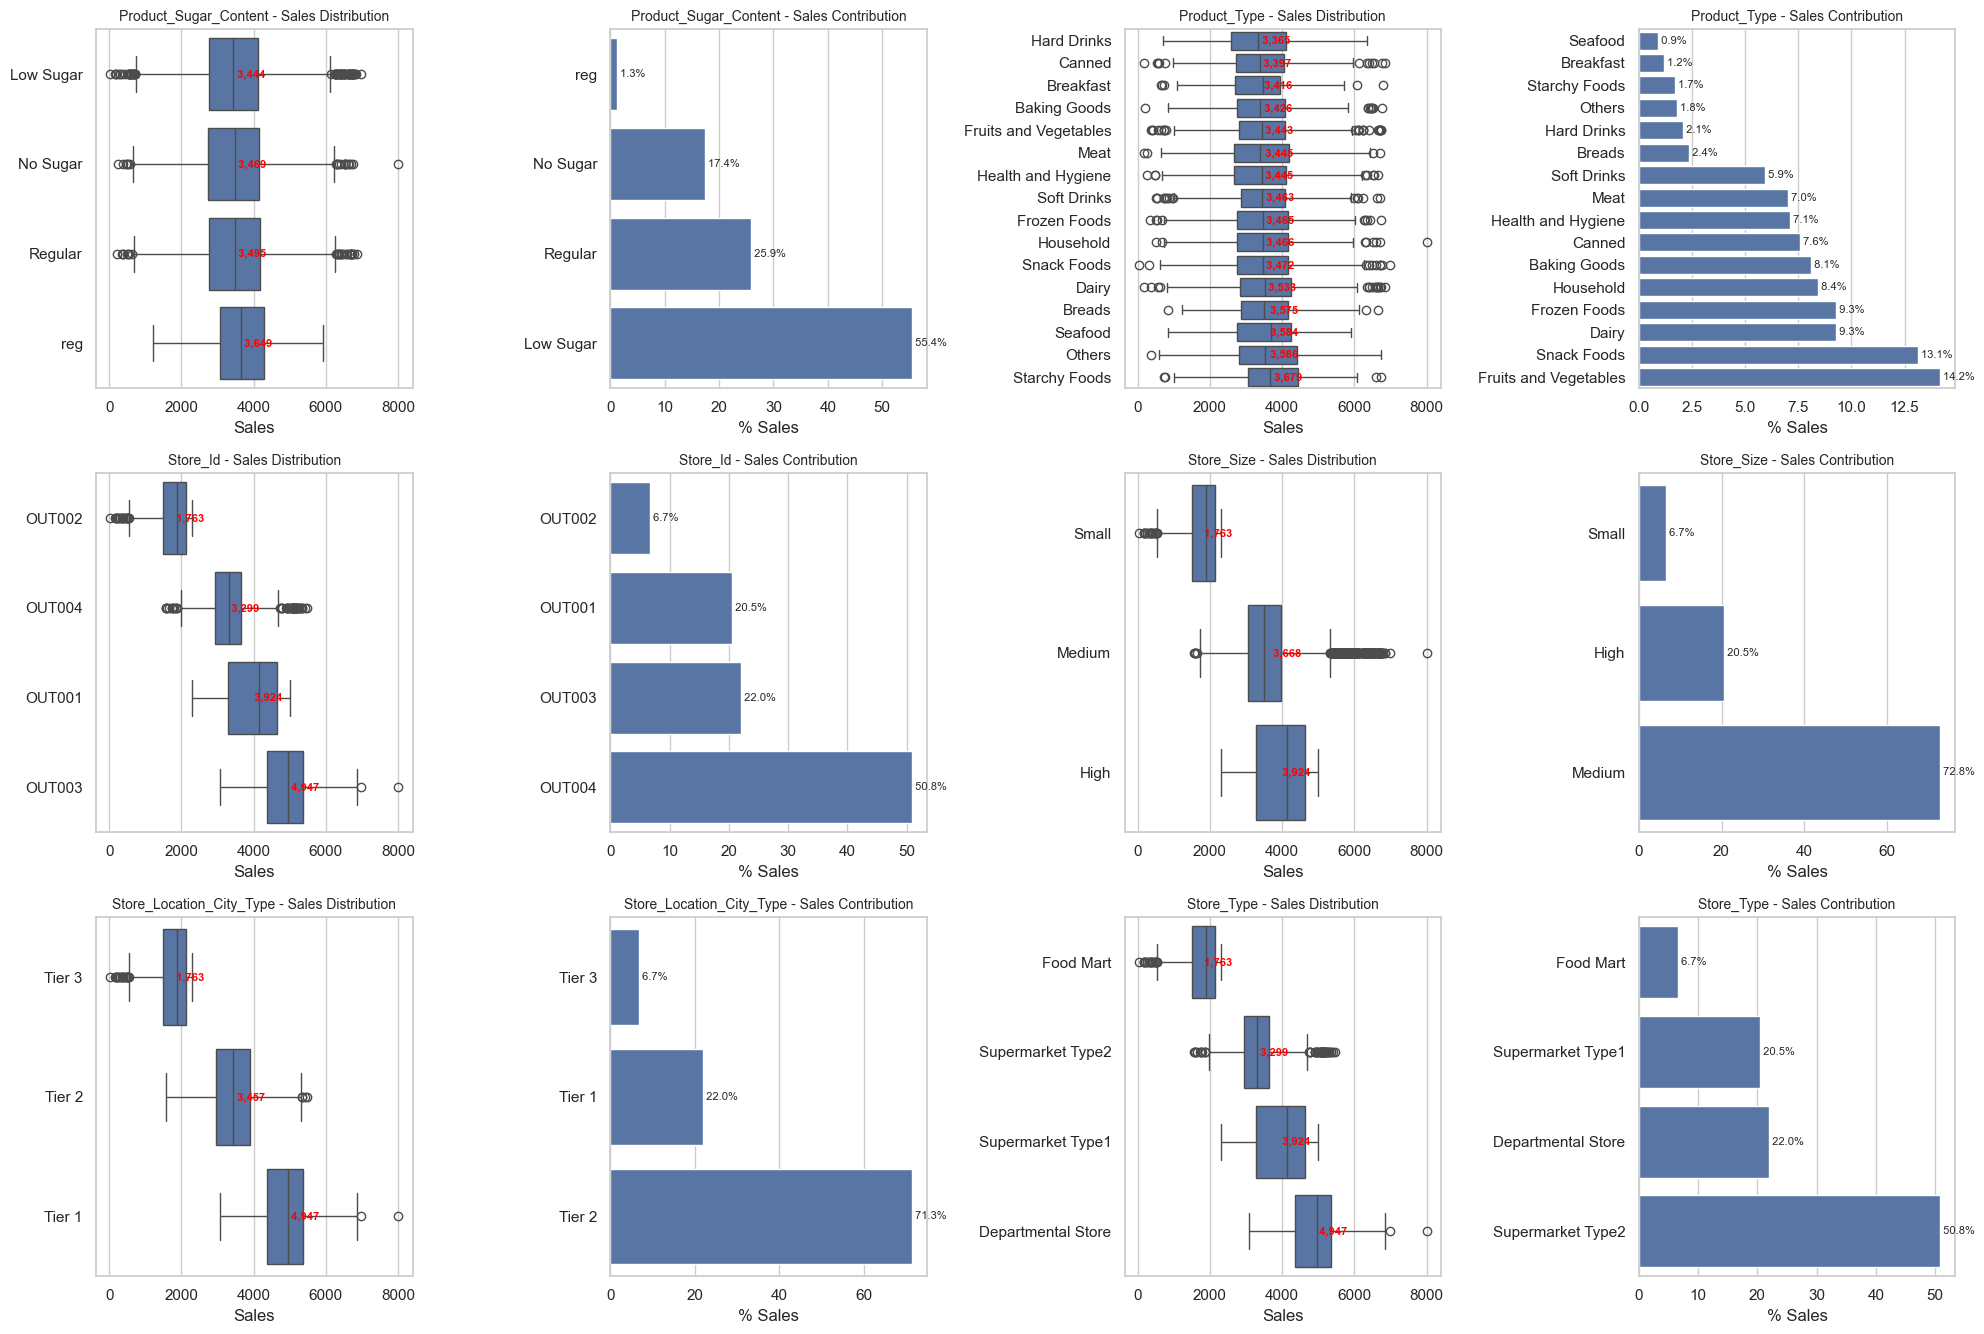

In [14]:
# plotting relationships between sales and categorical variables

plot_sales_relationships_c(kart, categorical_cols, target_col)  

**Categorical Bivariate Analysis Insights**

* **Store characteristics are the strongest categorical drivers of sales.** Medium-sized stores contribute the highest share of revenue (**72.8%**) and have higher average sales than Small stores. Similarly, **Tier 2 locations contribute 71.3%** of total sales, significantly outperforming Tier 1 and Tier 3 locations.

* **Store Type has a substantial impact on performance.** Supermarket Type 2 contributes **50.8%** of total sales and records the highest average sales (~4,947), making it the strongest-performing store format.

* **Product Type influences revenue concentration.** Fruits & Vegetables (**14.2%**) and Snack Foods (**13.1%**) are the largest contributors to sales, while categories such as Seafood (**0.9%**) and Breakfast (**1.2%**) contribute relatively little revenue.

* **Product Sugar Content shows differing revenue contributions despite similar sales distributions.** Low Sugar products account for **55.4%** of total sales compared to 25.9% for Regular products, suggesting consumer preference may favour lower-sugar offerings.

**Modelling Implications**

* **Store Size, Store Type, Store Location City Type, and Product Type** demonstrate strong discriminatory power and should be retained as important categorical predictors.
* The large differences in sales contribution across categories indicate that proper categorical encoding will be critical for model performance.
* Product Sugar Content may provide useful predictive value despite similar sales distributions because of its substantial variation in revenue contribution.
* These findings support proceeding with feature engineering and encoding of categorical variables before model development.


#### Categorical vs Numerical Variables

- This helps explain why some categories perform better: xample Questions: Do higher-MRP products belong to specific Product Types?, Are certain Store Types associated with larger product weights? Does Product Allocated Area vary by Store Size?

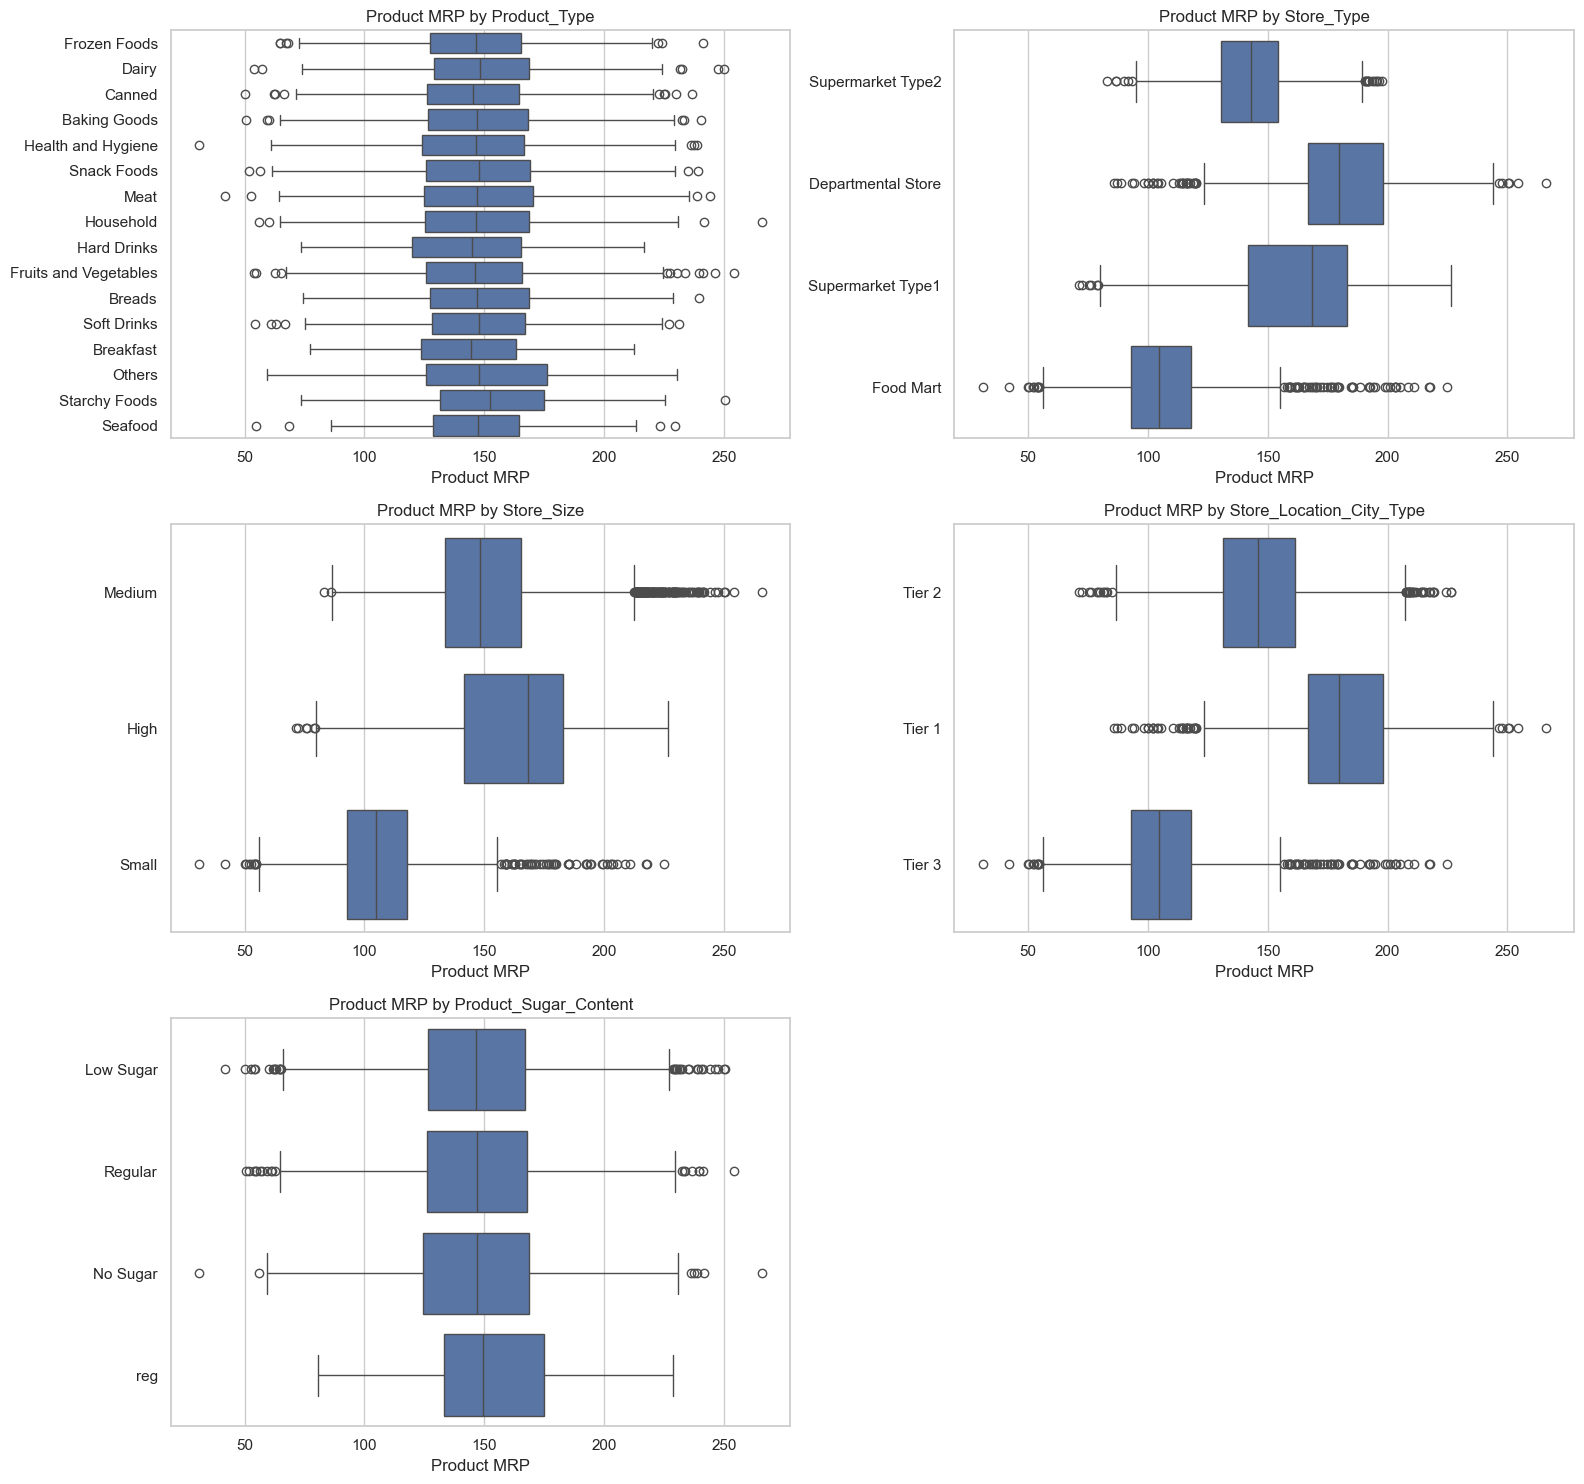

In [15]:
# Product MRP by Strongest categorical variables

mrp_category_cols = [
    "Product_Type",
    "Store_Type",
    "Store_Size",
    "Store_Location_City_Type",
    "Product_Sugar_Content"
]

rows = math.ceil(len(mrp_category_cols) / 2)

fig, axes = plt.subplots(
    rows,
    2,
    figsize=(16, 5 * rows)
)

axes = axes.flatten()

for ax, col in zip(axes, mrp_category_cols):

    sns.boxplot(
        data=kart,
        y=col,
        x="Product_MRP",
        ax=ax
    )

    ax.set_title(f"Product MRP by {col}")
    ax.set_xlabel("Product MRP")
    ax.set_ylabel("")

# Hide unused axes (if odd number of plots)
for ax in axes[len(mrp_category_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


**Product MRP by Category**

* **Store characteristics strongly influence pricing levels.** Products sold in **High-sized stores**, **Tier 1 cities**, and **Departmental Stores** generally command higher MRP values than those sold in smaller stores or lower-tier locations.

* **Food Marts consistently exhibit the lowest MRP distributions**, suggesting a focus on lower-priced products and value-driven customer segments.

* While Product Type shows some variation in MRP, the differences are less pronounced than those observed across Store Type, Store Size, and City Tier, indicating that store characteristics may be a stronger determinant of product pricing than product category itself.


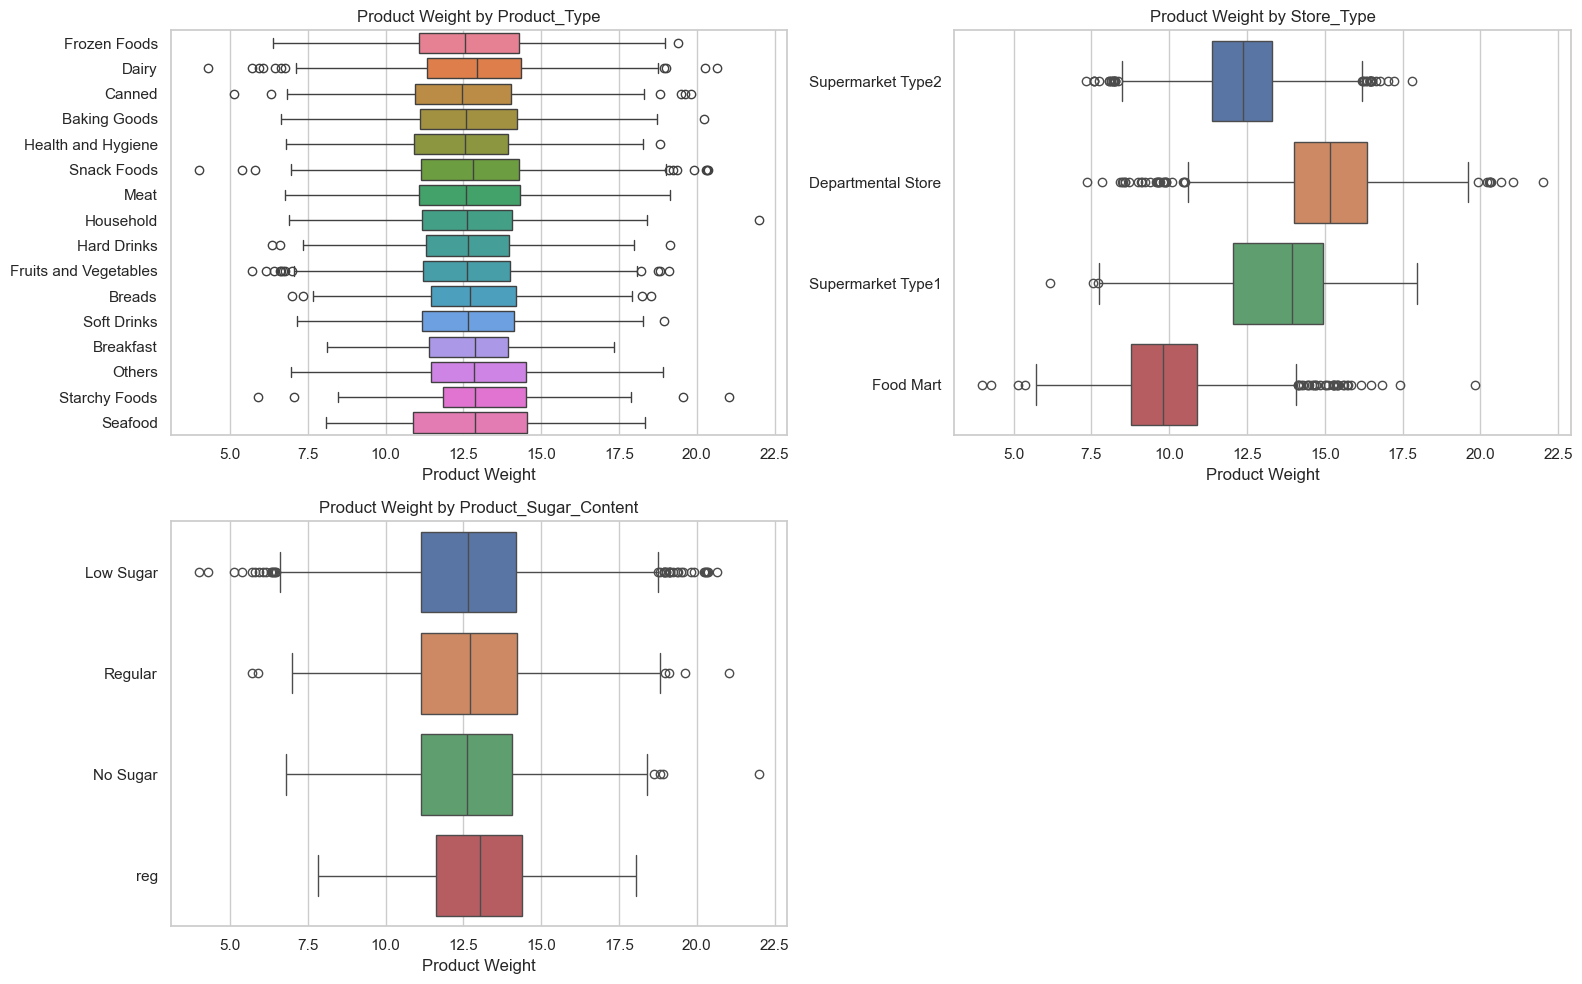

In [16]:
# Product Weight by Category

weight_category_cols = [
    "Product_Type",
    "Store_Type",
    "Product_Sugar_Content"
]

# compute number of rows needed
rows = (len(weight_category_cols) + 1) // 2

fig, axes = plt.subplots(
    rows,
    2,
    figsize=(16, 5 * rows)
)

# flatten axes for easy iteration
axes = axes.flatten()

for ax, col in zip(axes, weight_category_cols):

    sns.boxplot(
        data=kart,
        y=col,
        x="Product_Weight",
        ax=ax,
        hue=col
    )

    ax.set_title(f"Product Weight by {col}")
    ax.set_xlabel("Product Weight")
    ax.set_ylabel("")

# hide any unused subplot (e.g., last empty cell)
for ax in axes[len(weight_category_cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


**Product Weight by Category**

* **Product Weight varies considerably across Store Types**, with **Departmental Stores** and **Supermarket Type 1** generally carrying heavier products, while **Food Marts** stock lighter products on average.

* **Product Type exhibits relatively similar weight distributions**, with most categories centred around **12–14 units**, suggesting product weight alone may not strongly differentiate product categories.

* The presence of several outliers across categories indicates a wide range of product pack sizes, which may contribute to the strong positive relationship previously observed between **Product Weight and Sales (r = 0.74)**.

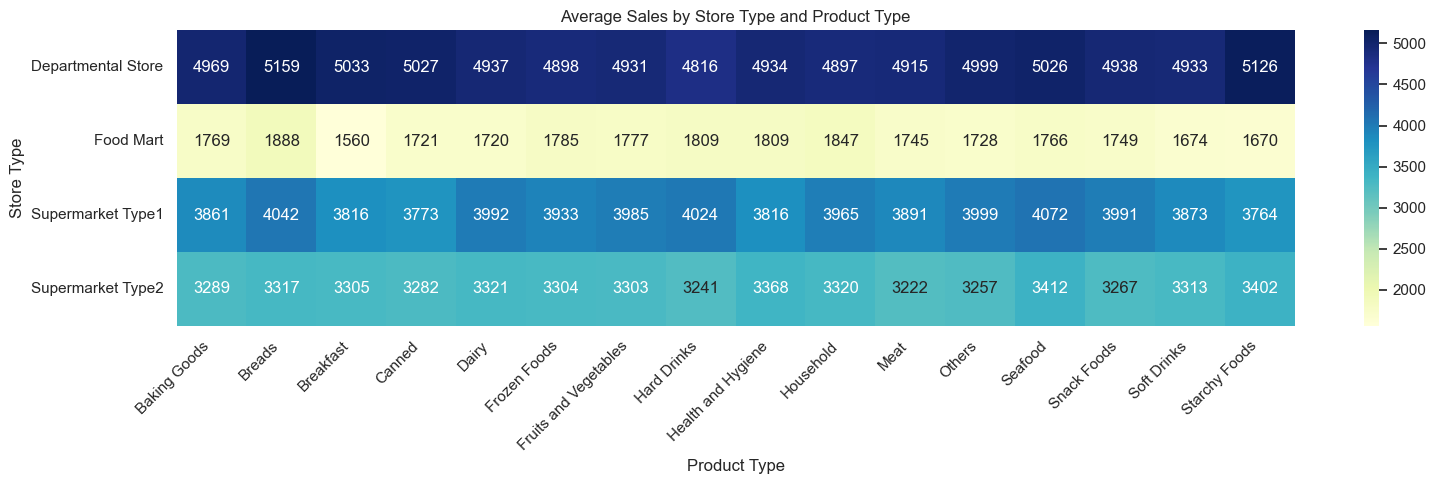

In [17]:
# C. Sales Interaction Heatmap : Store_Type × Product_Type → Average Sales

sales_interaction = pd.pivot_table(
    data=kart,
    values="Product_Store_Sales_Total",
    index="Store_Type",
    columns="Product_Type",
    aggfunc="mean"
)

plt.figure(figsize=(16, 5))

sns.heatmap(
    sales_interaction,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Average Sales by Store Type and Product Type")
plt.xlabel("Product Type")
plt.ylabel("Store Type")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Store Type × Product Type Sales Interaction**

* **Departmental Stores consistently generate the highest average sales across all product categories**, with average sales generally exceeding **4,800–5,100**, making them the strongest-performing store format.

* **Food Marts underperform across all product categories**, with average sales typically ranging between **1,500–1,900**, highlighting a significant performance gap relative to other store formats.

* The ranking of store formats remains largely consistent across product categories, suggesting that **store characteristics have a greater impact on sales performance than individual product categories**.


#### Bivariate Analysis Conclusion

The bivariate analysis confirms that both numerical and categorical variables contribute meaningfully to sales performance. Among numerical features, **Product MRP** and **Product Weight** emerge as the strongest predictors of sales, while categorical analyses reveal substantial differences across **Store Type, Store Size, City Tier, Product Type, and Product Sugar Content**.

The interaction analysis further demonstrates that store-related attributes consistently influence sales outcomes across multiple product categories, reinforcing their importance as predictive features. Additionally, the observed differences in pricing and product weight distributions across store segments suggest that these variables capture meaningful business patterns that can enhance model performance.

Overall, the analysis provides strong evidence that both numerical and categorical features contain valuable predictive information and should be retained for further modelling.

---
##  **Data Preprocessing**

Before model development, the dataset must be prepared to ensure that all features are suitable for machine learning algorithms. The preprocessing stage will focus on:

* Encoding categorical variables into machine-readable formats.
* Scaling numerical features where appropriate.
* Creating derived features such as **Store Age** from **Store Establishment Year**.
* Preparing the data pipeline for consistent processing during both training and prediction.

These steps will transform the raw analytical dataset into a model-ready dataset suitable for training and evaluating forecasting models.

In [18]:
# Create a copy of the original dataframe for modelling keeping only important modelling variables

selected_features = [
    # Numerical
    "Product_MRP",
    "Product_Weight",
    "Store_Establishment_Year",

    # Categorical
    "Product_Type",
    "Product_Sugar_Content",
    "Store_Type",
    "Store_Size",
    "Store_Location_City_Type",

    # Target
    "Product_Store_Sales_Total"
]

df_model = df[selected_features].copy()

In [19]:
# Create folders for deployment files / frontend if they don't exist

Path("deployment_files").mkdir(parents=True, exist_ok=True)

print("Deployment folders created.")

Path("frontend_files").mkdir(parents=True, exist_ok=True)
print("frontend_files folders created successfully.")

Deployment folders created.
frontend_files folders created successfully.


### Feature Engineering

**Feature Engineering Rationale**

- `Store_Age` was created replacing `Store_Establishment_Year` because the number of years a store has been operating may influence its sales maturity and customer base.

In [20]:
%%writefile deployment_files/feature_engineering.py

import pandas as pd

def create_features(df):
    df = df.copy()

    if "Store_Establishment_Year" in df.columns:
        current_year = pd.Timestamp.now().year
        df["Store_Age"] = current_year - df["Store_Establishment_Year"]
        df.drop(columns=["Store_Establishment_Year"], inplace=True)

    return df

Writing deployment_files/feature_engineering.py


In [21]:
# Create a FunctionTransformer for the feature engineering function

from deployment_files.feature_engineering import create_features

feature_engineer = FunctionTransformer(create_features, validate=False)

### Outlier Detection

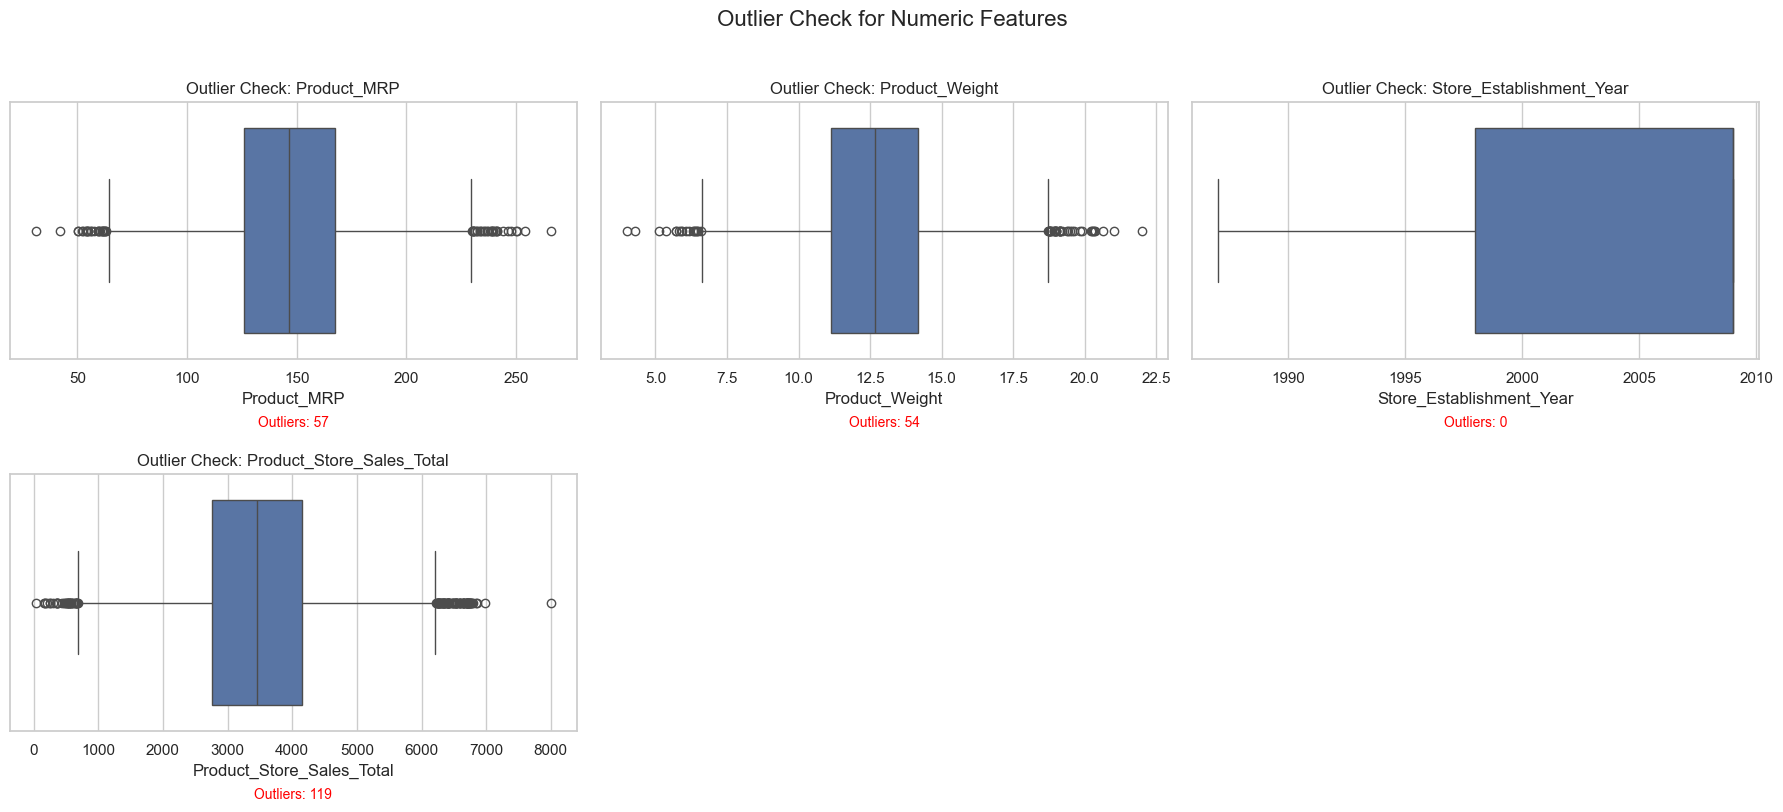

In [22]:
# Outlier detection and visualisation for numeric features

numeric_features = df_model.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Grid settings
n_cols = 3
n_rows = math.ceil(len(numeric_features) / n_cols)

plt.figure(figsize=(6 * n_cols, 4 * n_rows))
plt.suptitle("Outlier Check for Numeric Features", fontsize=16, y=1.02)

for i, col in enumerate(numeric_features, 1):
    ax = plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df_model[col], ax=ax)
    ax.set_title(f"Outlier Check: {col}")

    # ---- IQR Outlier Calculation ----
    Q1 = df_model[col].quantile(0.25)
    Q3 = df_model[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_model[(df_model[col] < lower) | (df_model[col] > upper)]
    outlier_count = outliers.shape[0]

    # ---- Add outlier count below each subplot ----
    ax.text(
        0.5, -0.25,
        f"Outliers: {outlier_count}",
        ha="center", va="center",
        transform=ax.transAxes,
        fontsize=10, color="red"
    )

plt.tight_layout()

**Outlier Treatment Rationale**

Outliers were checked using boxplots and the IQR method. Since this is a retail sales forecasting problem, high sales values and high MRP values can represent genuine business behaviour rather than data errors. Therefore, outliers were not removed. Tree-based models are also robust to outliers, so retaining them helps preserve real-world sales patterns.

### Train-Test Split

In [23]:
X = df_model.drop("Product_Store_Sales_Total", axis=1)
y = df_model["Product_Store_Sales_Total"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (7010, 8)
X_test shape: (1753, 8)
y_train shape: (7010,)
y_test shape: (1753,)


### Preprocessing Pipeline

In [24]:
# Apply feature engineering to the training data to identify numeric and categorical features for preprocessing

X_fe = create_features(X)

numeric_features = X_fe.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_features = X_fe.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numeric Features:", numeric_features)
print("Categorical Features:", categorical_features)

Numeric Features: ['Product_MRP', 'Product_Weight', 'Store_Age']
Categorical Features: ['Product_Type', 'Product_Sugar_Content', 'Store_Type', 'Store_Size', 'Store_Location_City_Type']


### Build Preprocessor

**Preprocessing Pipeline Rationale**

- Numerical features are imputed using the median because it is robust to outliers.
- Numerical features are scaled using StandardScaler.
- Categorical features are imputed using the most frequent category and encoded using OneHotEncoder.
- `handle_unknown="ignore"` ensures that unseen categories during prediction do not break the model.

In [25]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

feature_engineer = FunctionTransformer(
    create_features,
    validate=False
)

---
##  **Model Building**

### Model Evaluation Metrics

The main metric selected for model evaluation is RMSE.

| Metric | Purpose | Rationale | Interpretation |
|--------|---------|-----------|----------------|
| **RMSE** | Primary metric | Penalises large errors; critical for avoiding costly forecasting mistakes (stockouts, overstocking, procurement issues). | Lower = better accuracy; large errors punished more. |
| **MAE** | Supporting metric | Gives average error in sales units; less sensitive to outliers. | Lower = smaller typical error. |
| **MAPE** | Percentage‑based accuracy | Helps stakeholders understand average % deviation from actual sales. | Lower = better percentage accuracy. |
| **R²** | Model fit | Shows how much variance in sales is explained by the model. | Higher = model explains more variation. |
| **Adjusted R²** | Complexity‑aware fit | Penalises unnecessary predictors; useful after encoding many categorical features. | Higher = better fit after accounting for complexity. |

The best model will be selected mainly using the lowest Test RMSE, while also checking MAE, MAPE, R-squared, Adjusted R-squared, and the gap between train and test performance.

### Define functions for Model Evaluation

In [26]:
# Function to compute Adjusted R-squared

def adj_r2_score(predictors, targets, predictions):
    """
    Computes Adjusted R-squared

    predictors : independent variables
    targets    : actual target values
    predictions: predicted target values
    """

    r2 = r2_score(targets, predictions)

    n = predictors.shape[0]   # number of observations
    k = predictors.shape[1]   # number of predictors

    adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - k - 1))

    return adjusted_r2



In [27]:
# Function to evaluate model performance

def model_performance(model, X_train, y_train, X_test=None, y_test=None):

    # Training predictions
    train_pred = model.predict(X_train)

    performance = {
        "RMSE": [
            np.sqrt(mean_squared_error(y_train, train_pred))
        ],

        "MAE": [
            mean_absolute_error(y_train, train_pred)
        ],

        "R-squared": [
            r2_score(y_train, train_pred)
        ],

        "Adj. R-squared": [
            adj_r2_score(X_train, y_train, train_pred)
        ],

        "MAPE": [
            mean_absolute_percentage_error(y_train, train_pred)
        ]
    }

    # Test predictions (only if test data is provided)
    if X_test is not None and y_test is not None:

        test_pred = model.predict(X_test)

        performance.update({

            "Test RMSE": [
                np.sqrt(mean_squared_error(y_test, test_pred))
            ],

            "Test MAE": [
                mean_absolute_error(y_test, test_pred)
            ],

            "Test R-squared": [
                r2_score(y_test, test_pred)
            ],

            "Test Adj. R-squared": [
                adj_r2_score(X_test, y_test, test_pred)
            ],

            "Test MAPE": [
                mean_absolute_percentage_error(y_test, test_pred)
            ]
        })

    return pd.DataFrame(performance)

In [28]:
# Function to plot model comparison using grouped horizontal bar charts

def plot_model_comparison(results_df):
    """
    Plots model comparison using grouped horizontal bar charts.
    Lower is better for error metrics.
    Higher is better for score metrics.
    """

    error_metrics = ["Test RMSE", "Test MAE", "Test MAPE"]
    score_metrics = ["Test R-squared", "Test Adj. R-squared"]

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    # Error metrics - lower is better
    error_df = results_df[error_metrics].sort_values("Test RMSE")

    error_df.plot(
        kind="barh",
        ax=axes[0]
    )

    axes[0].set_title("Model Error Comparison - Lower is Better")
    axes[0].set_xlabel("Error Value")
    axes[0].set_ylabel("Model")
    axes[0].invert_yaxis()

    # Score metrics - higher is better
    score_df = results_df[score_metrics].sort_values(
        "Test Adj. R-squared",
        ascending=True
    )

    score_df.plot(
        kind="barh",
        ax=axes[1]
    )

    axes[1].set_title("Model Score Comparison - Higher is Better")
    axes[1].set_xlabel("Score")
    axes[1].set_ylabel("Model")

    plt.tight_layout()
    plt.show()

In [29]:
# Function to plot regression diagnostics (Actual vs Predicted, Error Distribution, Residual Plot)

def regression_diagnostics(y_true, y_pred):

    errors = y_true - y_pred

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    # Actual vs Predicted
    sns.scatterplot(
        x=y_true,
        y=y_pred,
        ax=axes[0]
    )

    axes[0].plot(
        [y_true.min(), y_true.max()],
        [y_true.min(), y_true.max()],
        color="red",
        linestyle="--"
    )

    axes[0].set_title("Actual vs Predicted")
    axes[0].set_xlabel("Actual Sales")
    axes[0].set_ylabel("Predicted Sales")

    # Error Distribution
    sns.histplot(
        errors,
        kde=True,
        ax=axes[1]
    )

    axes[1].axvline(
        0,
        color="red",
        linestyle="--"
    )

    axes[1].set_title("Error Distribution")
    axes[1].set_xlabel("Prediction Error")

    # Residual Plot
    sns.scatterplot(
        x=y_pred,
        y=errors,
        ax=axes[2]
    )

    axes[2].axhline(
        0,
        color="red",
        linestyle="--"
    )

    axes[2].set_title("Residual Plot")
    axes[2].set_xlabel("Predicted Sales")
    axes[2].set_ylabel("Residuals")

    plt.tight_layout()
    plt.show()

### ML Models

To support SuperKart’s goal of forecasting quarterly outlet‑level sales for improved inventory and regional planning, several machine learning models—specifically tree‑based and ensemble methods such as **Decision Tree**, **Random Forest**, **AdaBoost**, **Gradient Boosting**, and **XGBoost**—were trained and evaluated. Model performance was assessed on both training and test datasets to ensure reliable learning and robust generalization, enabling the detection of **overfitting**, **underfitting**, and **good generalization** essential for deploying an accurate forecasting solution across SuperKart’s stores.

#### 1. Decision Tree Regressor

In [30]:
dt_pipeline = Pipeline(
    steps=[
        ("feature_engineering", feature_engineer),
        ("preprocessor", preprocessor),
        ("model", DecisionTreeRegressor(
            random_state=42,
            max_depth=6,
            min_samples_split=20,
            min_samples_leaf=10
        ))
    ]
)

dt_pipeline.fit(X_train, y_train)

dt_perf = model_performance(
    dt_pipeline,
    X_train,
    y_train,
    X_test,
    y_test
)

dt_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE,Test RMSE,Test MAE,Test R-squared,Test Adj. R-squared,Test MAPE
0,317.274131,191.296994,0.911235,0.911134,0.070497,336.357814,200.884092,0.900846,0.900391,0.071328


#### 2. Random Forest Regressor

In [31]:
rf_pipeline = Pipeline(
    steps=[
        ("feature_engineering", feature_engineer),
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(random_state=42, n_jobs=-1))
    ]
)

rf_pipeline.fit(X_train, y_train)

rf_perf = model_performance(rf_pipeline,     X_train,
    y_train,
    X_test,
    y_test)

rf_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE,Test RMSE,Test MAE,Test R-squared,Test Adj. R-squared,Test MAPE
0,107.278096,39.627352,0.989852,0.98984,0.014932,286.209763,108.207319,0.928208,0.927879,0.038732


#### 3. Gradient Boosting Regressor 

In [32]:
gb_pipeline = Pipeline(
    steps=[
        ("feature_engineering", feature_engineer),
        ("preprocessor", preprocessor),
        ("model", GradientBoostingRegressor(random_state=42))
    ]
)

gb_pipeline.fit(X_train, y_train)

gb_perf = model_performance(gb_pipeline,     X_train,
    y_train,
    X_test,
    y_test)

gb_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE,Test RMSE,Test MAE,Test R-squared,Test Adj. R-squared,Test MAPE
0,295.030495,136.659666,0.923245,0.923158,0.050376,312.755085,146.753408,0.914273,0.91388,0.0516


#### 4. AdaBoost Regressor 

In [33]:
ada_pipeline = Pipeline(
    steps=[
        ("feature_engineering", feature_engineer),
        ("preprocessor", preprocessor),
        ("model", AdaBoostRegressor(random_state=42))
    ]
)

ada_pipeline.fit(X_train, y_train)

ada_perf = model_performance(ada_pipeline,     X_train,
    y_train,
    X_test,
    y_test)

ada_perf


,RMSE,MAE,R-squared,Adj. R-squared,MAPE,Test RMSE,Test MAE,Test R-squared,Test Adj. R-squared,Test MAPE
0,490.956591,383.02717,0.787452,0.787209,0.134905,489.28087,379.914965,0.790191,0.789229,0.132043


#### 5. XGBoost Base Model

In [34]:
xgb_pipeline = Pipeline(
    steps=[
        ("feature_engineering", feature_engineer),
        ("preprocessor", preprocessor),
        ("model", XGBRegressor(
            random_state=42,
            objective="reg:squarederror",
            n_jobs=-1
        ))
    ]
)

xgb_pipeline.fit(X_train, y_train)

xgb_perf = model_performance(
    xgb_pipeline,
    X_train,
    y_train,
    X_test,
    y_test
)

xgb_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE,Test RMSE,Test MAE,Test R-squared,Test Adj. R-squared,Test MAPE
0,146.066838,65.498291,0.981186,0.981165,0.024165,308.683402,132.265793,0.916491,0.916108,0.04826


### Base Model Comparison

In [35]:
# Compile base model results into a single DataFrame for comparison

base_model_results = pd.concat(
    [
        dt_perf,
        rf_perf,
        gb_perf,
        ada_perf,
        xgb_perf
    ],
    axis=0
)

base_model_results.index = [
    "Decision Tree",
    "Random Forest",
    "Gradient Boosting",
    "AdaBoost",
    "XGBoost"
]

base_model_results
base_model_results.sort_values(by="Test RMSE").T

,Random Forest,XGBoost,Gradient Boosting,Decision Tree,AdaBoost
RMSE,107.278096,146.066838,295.030495,317.274131,490.956591
MAE,39.627352,65.498291,136.659666,191.296994,383.027170
R-squared,0.989852,0.981186,0.923245,0.911235,0.787452
Adj. R-squared,0.989840,0.981165,0.923158,0.911134,0.787209
MAPE,0.014932,0.024165,0.050376,0.070497,0.134905
Test RMSE,286.209763,308.683402,312.755085,336.357814,489.280870
Test MAE,108.207319,132.265793,146.753408,200.884092,379.914965
Test R-squared,0.928208,0.916491,0.914273,0.900846,0.790191
Test Adj. R-squared,0.927879,0.916108,0.913880,0.900391,0.789229
Test MAPE,0.038732,0.048260,0.051600,0.071328,0.132043


**Base Model Performance Comments**
H
- **Random Forest** delivers the strongest forecasting capability, with the **lowest test RMSE (286.21)**, **lowest test MAE (108.21)**, and **highest test R² (0.928)**, making it the most reliable model for SuperKart’s quarterly sales prediction objective.  
- **XGBoost** performs consistently well, with **test RMSE 308.68** and **test R² 0.916**, offering strong generalization and stable error levels suitable for deployment.  
- **Gradient Boosting** shows moderate accuracy (**test RMSE 312.76**, **test R² 0.914**) but higher errors than Random Forest and XGBoost, indicating less robustness for revenue forecasting.  
- **Decision Tree** exhibits noticeable overfitting (train R² 0.911 vs. test R² 0.901) and higher test errors (**RMSE 336.36**), making it less suitable for precise sales forecasting.  
- **AdaBoost** performs the weakest, with the **highest test RMSE (489.28)** and **lowest test R² (0.790)**, indicating poor predictive reliability for SuperKart’s forecasting needs.

Here is a **short, sharp one‑liner** you can add to justify hyperparameter tuning:

To reduce prediction errors and improve model generalization, **Hyperparameter tuning** was performed ensuring the forecasting models align with SuperKart’s objective of producing accurate and reliable quarterly sales predictions.

---
##  **Model Performance Improvement - Hyperparameter Tuning**

### Tunning Params

In [36]:
# Hyperparameter tuning parameters for each model to be used in RandomizedSearchCV

tuning_configs = {

    "Decision Tree": {
        "pipeline": dt_pipeline,
        "params": {
            "model__max_depth": [3, 5, 7, 10, 15],
            "model__min_samples_split": [10, 20, 30, 50],
            "model__min_samples_leaf": [5, 10, 15, 20],
            "model__max_features": [None, "sqrt", "log2"]
        }
    },

    "Random Forest": {
        "pipeline": rf_pipeline,
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [None, 5, 10, 15, 20],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
            "model__max_features": ["sqrt", "log2", None]
        }
    },


    "Gradient Boosting": {
        "pipeline": gb_pipeline,
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
            "model__max_depth": [2, 3, 4, 5],
            "model__min_samples_split": [2, 5, 10],
            "model__min_samples_leaf": [1, 2, 4],
            "model__subsample": [0.8, 0.9, 1.0]
        }
    },

    "AdaBoost": {
        "pipeline": ada_pipeline,
        "params": {
            "model__n_estimators": [50, 100, 200, 300],
            "model__learning_rate": [0.01, 0.05, 0.1, 0.5, 1.0],
            "model__loss": ["linear", "square", "exponential"]
        }
    },

    "XGBoost": {
        "pipeline": xgb_pipeline,
        "params": {
            "model__max_depth": [3,4,5,6,8],
            "model__min_child_weight": [1,3,5],
            "model__gamma": [0,0.1,0.2],
            "model__subsample": [0.7,0.8,0.9,1.0],
            "model__colsample_bytree": [0.7,0.8,0.9,1.0], # percentage of attributes to be considered (randomly) for each tree
            "model__colsample_bylevel": [0.7,0.8,0.9,1.0], # percentage of attributes to be considered (randomly) for each level of a tree
            "model__learning_rate": [0.01,0.03,0.05,0.1],
            "model__n_estimators": [200,300,500],
            "model__reg_lambda": [0.4, 0.5, 0.6]     # L2 regularization factor
        }
    }
}




### Tune selected Models

In [37]:
# Hyperparameter tuning using RandomizedSearchCV for each model and compiling results

tuned_models = {}
tuned_results = []

for model_name, config in tuning_configs.items():

    print(f"Tuning {model_name}...")

    random_search = RandomizedSearchCV(
        estimator=config["pipeline"],
        param_distributions=config["params"],
        n_iter=20,
        scoring="neg_root_mean_squared_error",
        cv=5,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

    random_search.fit(X_train, y_train)

    best_model = random_search.best_estimator_

    tuned_models[f"Tuned {model_name}"] = best_model

    perf = model_performance(
        best_model,
        X_train,
        y_train,
        X_test,
        y_test
    )

    perf.index = [f"Tuned {model_name}"]
    tuned_results.append(perf)

    print(f"Best Parameters for {model_name}:")
    print(random_search.best_params_)

    print(f"Best CV RMSE for {model_name}:")
    print(-random_search.best_score_)

    print("-" * 80)

Tuning Decision Tree...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters for Decision Tree:
{'model__min_samples_split': 10, 'model__min_samples_leaf': 15, 'model__max_features': None, 'model__max_depth': 10}
Best CV RMSE for Decision Tree:
316.05466826967836
--------------------------------------------------------------------------------
Tuning Random Forest...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters for Random Forest:
{'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 2, 'model__max_features': None, 'model__max_depth': None}
Best CV RMSE for Random Forest:
283.63168813072656
--------------------------------------------------------------------------------
Tuning Gradient Boosting...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters for Gradient Boosting:
{'model__subsample': 0.9, 'model__n_estimators': 200, 'model__min_samples_split': 2, 'model__min_sampl

In [38]:
# Combine all tuned model results into a single DataFrame
tuned_model_results = pd.concat(tuned_results)
tuned_model_results.sort_values(by="Test RMSE").T

,Tuned Random Forest,Tuned XGBoost,Tuned Gradient Boosting,Tuned Decision Tree,Tuned AdaBoost
RMSE,200.671972,199.557271,230.103994,276.588867,452.802090
MAE,72.150631,80.168422,95.440103,128.641328,348.003649
R-squared,0.964490,0.964884,0.953310,0.932541,0.819204
Adj. R-squared,0.964450,0.964844,0.953257,0.932464,0.818998
MAPE,0.027662,0.029784,0.034340,0.048875,0.126155
Test RMSE,278.582391,282.247207,285.603114,294.490378,453.939237
Test MAE,105.357438,116.205982,119.933186,138.759086,350.732017
Test R-squared,0.931984,0.930182,0.928512,0.923994,0.819406
Test Adj. R-squared,0.931672,0.929862,0.928184,0.923645,0.818578
Test MAPE,0.038086,0.041945,0.043498,0.051214,0.123708


**Tuned Model Performance Comments (with reference to base models)**

- **Tuned Random Forest** shows clear improvement over the base model, reducing test RMSE from **286.21 → 278.58** and increasing test R² from **0.928 → 0.932**, strengthening its position as the most accurate model for SuperKart’s quarterly sales forecasting.  
- **Tuned XGBoost** also improves upon its base version, with test RMSE decreasing from **308.68 → 282.25** and test R² rising from **0.916 → 0.930**, making it a strong, scalable alternative.  
- **Tuned Gradient Boosting** shows moderate gains over the base model (test RMSE **312.76 → 285.60**), but still performs slightly below the top two models in forecasting accuracy.  
- **Tuned Decision Tree** improves from its base performance (test RMSE **336.36 → 294.49**), yet remains less reliable for precise revenue prediction due to higher residual error.  
- **Tuned AdaBoost** remains the weakest performer, with minimal improvement and the highest test RMSE (**453.94**) and lowest test R² (**0.819**), making it unsuitable for SuperKart’s forecasting objective.

---
##  **Model Performance Comparison, Final Model Selection, and Serialization**

### Model Performance Comparison

,Tuned Random Forest,Tuned XGBoost,Tuned Gradient Boosting,Random Forest,Tuned Decision Tree,XGBoost,Gradient Boosting,Decision Tree,Tuned AdaBoost,AdaBoost
RMSE,200.671972,199.557271,230.103994,107.278096,276.588867,146.066838,295.030495,317.274131,452.802090,490.956591
MAE,72.150631,80.168422,95.440103,39.627352,128.641328,65.498291,136.659666,191.296994,348.003649,383.027170
R-squared,0.964490,0.964884,0.953310,0.989852,0.932541,0.981186,0.923245,0.911235,0.819204,0.787452
Adj. R-squared,0.964450,0.964844,0.953257,0.989840,0.932464,0.981165,0.923158,0.911134,0.818998,0.787209
MAPE,0.027662,0.029784,0.034340,0.014932,0.048875,0.024165,0.050376,0.070497,0.126155,0.134905
Test RMSE,278.582391,282.247207,285.603114,286.209763,294.490378,308.683402,312.755085,336.357814,453.939237,489.280870
Test MAE,105.357438,116.205982,119.933186,108.207319,138.759086,132.265793,146.753408,200.884092,350.732017,379.914965
Test R-squared,0.931984,0.930182,0.928512,0.928208,0.923994,0.916491,0.914273,0.900846,0.819406,0.790191
Test Adj. R-squared,0.931672,0.929862,0.928184,0.927879,0.923645,0.916108,0.913880,0.900391,0.818578,0.789229
Test MAPE,0.038086,0.041945,0.043498,0.038732,0.051214,0.048260,0.051600,0.071328,0.123708,0.132043


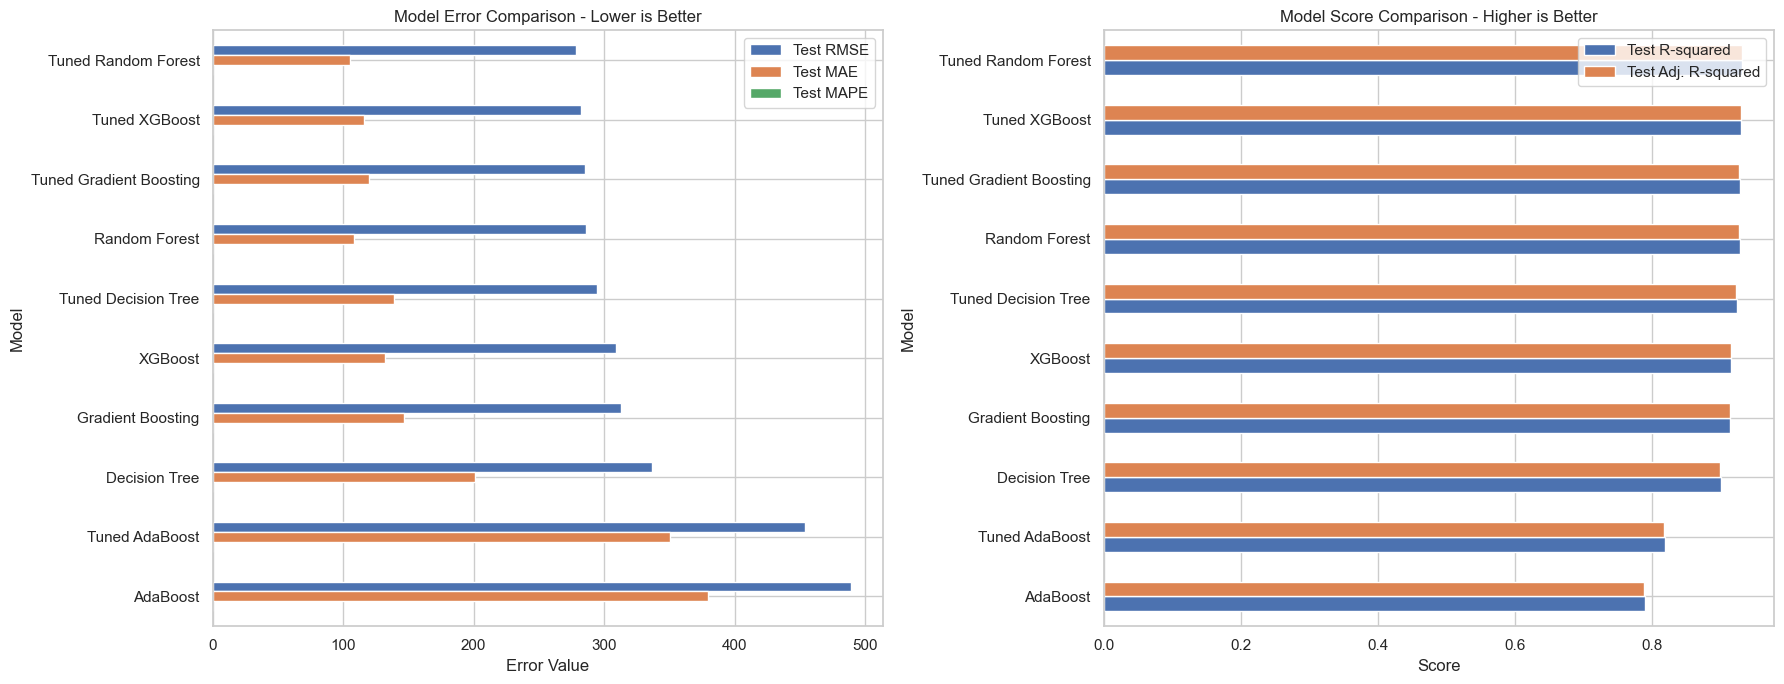

In [39]:
# Combine base model results and tuned model results into a single DataFrame for comparison

all_model_results = pd.concat(
    [
        base_model_results,
        tuned_model_results
    ],
    axis=0
)


display(
    all_model_results.sort_values(by="Test RMSE").T
)

plot_model_comparison(all_model_results)

**Observations**

- **Tuned Random Forest** and **Tuned XGBoost** clearly outperform all other models, achieving the **lowest test errors** (RMSE ~278–282) and **highest test R²** (~0.93), showing that tuning strengthened their suitability for SuperKart’s quarterly sales forecasting objective.  
- Tuning consistently **reduced error and improved stability** across most models, with Gradient Boosting and Decision Tree showing noticeable gains, though still trailing the top ensemble methods.  
- **AdaBoost (base and tuned)** remains the weakest performer, with **significantly higher test RMSE (454–489)** and **lower test R² (~0.79–0.82)**, confirming it is unsuitable for accurate revenue forecasting in this context.

### Final Model Selection

In [40]:
# Get best model name based on lowest Test RMSE

best_model_name = all_model_results["Test RMSE"].idxmin()

print("Best Model:", best_model_name)

# Combine all models into one dictionary
all_models = {
    "Decision Tree": dt_pipeline,
    "Random Forest": rf_pipeline,
    "Gradient Boosting": gb_pipeline,
    "AdaBoost": ada_pipeline,
    "XGBoost": xgb_pipeline,
    **tuned_models
}

# Select final model
final_model = all_models[best_model_name]

final_model

Best Model: Tuned Random Forest


,steps,"[('feature_engineering', ...), ('preprocessor', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,func,<function cre...t 0x1229918a0>
,inverse_func,None
,validate,False
,accept_sparse,False
,check_inverse,True
,feature_names_out,None
,kw_args,None


**Final Model Selection Rationale**

The **Tuned Random Forest** is selected as the final model because it delivers the **lowest test error** (RMSE **278.58**) and the **highest predictive accuracy** (test R² **0.932**. It provides the best balance between low forecasting error, good explanatory power, and generalisation to unseen data making it the most reliable for SuperKart’s quarterly sales forecasting needs. **Tuned XGBoost** performs similarly well and serves as a strong secondary option, but Random Forest provides slightly better stability and lower error. Overall, the tuned ensemble models best support SuperKart’s objective of generating accurate, store‑level revenue forecasts to guide inventory and regional planning decisions.

### Final Model Test Performance

In [41]:
# Evaluate final model performance on training and test data

final_model_perf = model_performance(
    final_model,
    X_train,
    y_train,
    X_test,
    y_test
)

final_model_perf

,RMSE,MAE,R-squared,Adj. R-squared,MAPE,Test RMSE,Test MAE,Test R-squared,Test Adj. R-squared,Test MAPE
0,200.671972,72.150631,0.96449,0.96445,0.027662,278.582391,105.357438,0.931984,0.931672,0.038086


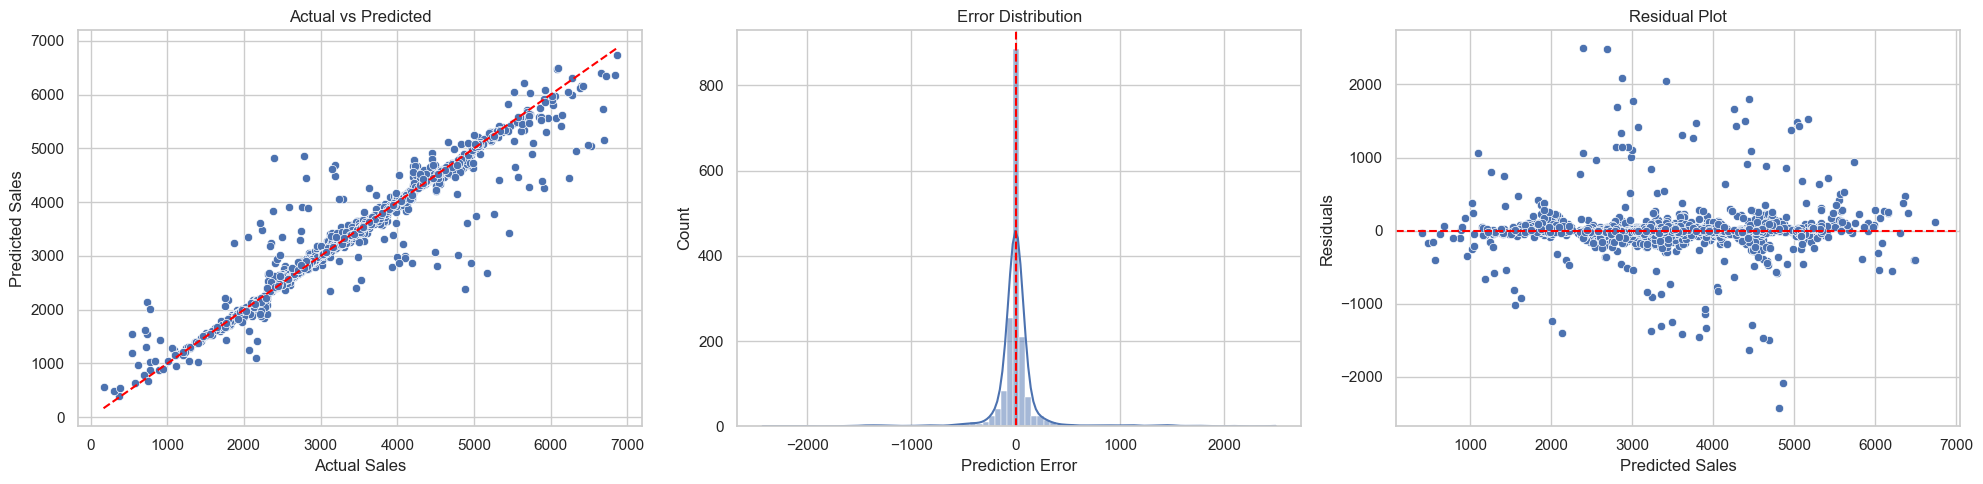

In [42]:
# Compare actual vs predicted values
predictions = final_model.predict(X_test)

regression_diagnostics(y_test, predictions)

**Prediction Result Interpretation**

- The **Tuned Random Forest** demonstrates strong generalization, with **Test RMSE 278.58**, **Test MAE 105.36**, and **Test R² 0.932**, indicating accurate and stable quarterly sales predictions on unseen data.  
- Error levels remain **low and well‑distributed**, as shown by the **MAPE of 0.038**, confirming that most predictions deviate only slightly from actual sales—critical for SuperKart’s revenue‑planning objective.  
- The residual and error‑distribution patterns show **no major bias or systematic error**, meaning the model captures underlying sales behaviour effectively and is reliable for deployment across store locations.

### Serialize Final Model

In [43]:
# save final best model metrics to a json file for later use in the API
best_metrics = all_model_results.loc[best_model_name]

model_metrics = {
    "model_name": best_model_name,
    "model_version": "v1.0",
    "test_rmse": float(best_metrics["Test RMSE"]),
    "test_mae": float(best_metrics["Test MAE"]),
    "test_r2": float(best_metrics["Test R-squared"]),
    "test_adj_r2": float(best_metrics["Test Adj. R-squared"]),
    "test_mape": float(best_metrics["Test MAPE"])
}

with open("frontend_files/model_metrics.json", "w") as f:
    json.dump(model_metrics, f, indent=4)

model_metrics

{'model_name': 'Tuned Random Forest',
 'model_version': 'v1.0',
 'test_rmse': 278.58239066505695,
 'test_mae': 105.35743755832834,
 'test_r2': 0.9319835333261685,
 'test_adj_r2': 0.9316715311854629,
 'test_mape': 0.03808646916486757}

In [ ]:
# Create a folder for storing the files needed for web app deployment

os.makedirs("deployment_files", exist_ok=True)

# Define the file path to save (serialize) the trained model along with the data preprocessing steps
saved_model_path = "deployment_files/superkart_sales_forecasting_model_v1_0.joblib"

# Save the best trained model pipeline using joblib
joblib.dump(final_model, saved_model_path)

print(f"Model saved successfully at {saved_model_path}")

Model saved successfully at deployment_files/superkart_sales_forecasting_model_v1_0.joblib


In [45]:
# Save raw input columns required by the API/user input:  Store_Establishment_Year is kept because the pipeline uses it to create Store_Age

with open("deployment_files/model_input_columns.json", "w") as f:
    json.dump(list(X_train.columns), f)

print("Raw input columns saved to deployment_files/model_input_columns.json")
print("Raw input columns:", X_train.columns.tolist())

# Save engineered columns for documentation/reference only: These are the columns actually passed into the preprocessor after feature engineering
engineered_columns = create_features(X_train).columns.tolist()

with open("deployment_files/engineered_model_columns.json", "w") as f:
    json.dump(engineered_columns, f)

print("\n------------------------------\n")
print("Engineered model columns saved to deployment_files/engineered_model_columns.json")
print("Engineered model columns:", engineered_columns)

Raw input columns saved to deployment_files/model_input_columns.json
Raw input columns: ['Product_MRP', 'Product_Weight', 'Store_Establishment_Year', 'Product_Type', 'Product_Sugar_Content', 'Store_Type', 'Store_Size', 'Store_Location_City_Type']

------------------------------

Engineered model columns saved to deployment_files/engineered_model_columns.json
Engineered model columns: ['Product_MRP', 'Product_Weight', 'Product_Type', 'Product_Sugar_Content', 'Store_Type', 'Store_Size', 'Store_Location_City_Type', 'Store_Age']


### Load Serialized Model and Make Predictions

In [46]:
# Load model + JSON column files to verify they were saved correctly and can be loaded without issues

loaded_model = joblib.load("deployment_files/superkart_sales_forecasting_model_v1_0.joblib")

with open("deployment_files/model_input_columns.json", "r") as f:
    loaded_columns = json.load(f)

with open("deployment_files/engineered_model_columns.json", "r") as f:
    loaded_engineered_columns = json.load(f)

print("Loaded model successfully")
print("Model input columns:", loaded_columns)
print("Engineered model columns:", loaded_engineered_columns)

Loaded model successfully
Model input columns: ['Product_MRP', 'Product_Weight', 'Store_Establishment_Year', 'Product_Type', 'Product_Sugar_Content', 'Store_Type', 'Store_Size', 'Store_Location_City_Type']
Engineered model columns: ['Product_MRP', 'Product_Weight', 'Product_Type', 'Product_Sugar_Content', 'Store_Type', 'Store_Size', 'Store_Location_City_Type', 'Store_Age']


In [47]:
# Make predictions with the loaded model to verify it works correctly after loading

loaded_predictions = loaded_model.predict(X_test)

loaded_model_perf = pd.DataFrame(
    {
        "RMSE": [np.sqrt(mean_squared_error(y_test, loaded_predictions))],
        "MAE": [mean_absolute_error(y_test, loaded_predictions)],
        "MAPE": [mean_absolute_percentage_error(y_test, loaded_predictions)],
        "R-squared": [r2_score(y_test, loaded_predictions)],
        "Adj. R-squared": [adj_r2_score(X_test, y_test, loaded_predictions)]
    }
)

loaded_model_perf

,RMSE,MAE,MAPE,R-squared,Adj. R-squared
0,278.582391,105.357438,0.038086,0.931984,0.931672


**Serialization Check**

The final model was successfully serialized with Joblib and reloaded without issues. Predictions generated from the reloaded model matched expected performance, confirming that the serialized artifact functions correctly. This validated model is ready for deployment within the Flask API, enabling fast, consistent sales forecasts without retraining.

### Create Sample Input for Deployment

In [48]:
# Using the same test set to verify loaded model performance matches original performance

loaded_model.predict(X_test)

array([3274.74743608, 3340.40326717, 2404.88814473, ..., 4132.71688566,
       2835.39909405, 4529.19330732], shape=(1753,))

In [49]:
# Select one sample record from the test dataset: This will be used to test deployment predictions

sample_input = X_test.iloc[[0]]

# Get actual sales value
actual_sales = y_test.iloc[0]

# Generate prediction using the loaded model
sample_prediction = loaded_model.predict(sample_input)[0]

# Compare actual vs predicted sales
print("Actual Sales:", round(actual_sales, 2))
print("Predicted Sales:", round(sample_prediction, 2))
print("Prediction Error:", round(actual_sales - sample_prediction, 2))

Actual Sales: 3396.37
Predicted Sales: 3274.75
Prediction Error: 121.62


In [50]:
# Convert sample input into dictionary format: This format can be used directly in API requests
sample_payload = sample_input.iloc[0].to_dict()

sample_payload

{'Product_MRP': 145.62,
 'Product_Weight': 12.53,
 'Store_Establishment_Year': 2009,
 'Product_Type': 'Snack Foods',
 'Product_Sugar_Content': 'Regular',
 'Store_Type': 'Supermarket Type2',
 'Store_Size': 'Medium',
 'Store_Location_City_Type': 'Tier 2'}

---
##  **Deployment - Backend - Docker Space**

### Create Backend Files (app.py (FLASK API), Dockerfile, requirements.txt, .dockerignore)

In [51]:
%%writefile deployment_files/app.py

from flask import Flask, request, jsonify
import pandas as pd
import joblib
import json
from pathlib import Path

app = Flask(__name__)

# Base directory of app.py
BASE_DIR = Path(__file__).resolve().parent

# Load model
model = joblib.load(
    BASE_DIR / "superkart_sales_forecasting_model_v1_0.joblib"
)

# Load raw input columns expected by the API
with open(BASE_DIR / "model_input_columns.json", "r") as f:
    input_columns = json.load(f)


@app.route("/", methods=["GET"])
def home():
    return jsonify({
        "message": "SuperKart Sales Forecasting API is running"
    })


@app.route("/health", methods=["GET"])
def health():
    return jsonify({
        "status": "healthy",
        "model_loaded": True,
        "input_columns": input_columns
    })


@app.route("/predict", methods=["POST"])
def predict():
    try:
        data = request.get_json()

        if data is None:
            return jsonify({
                "error": "No JSON payload received"
            }), 400

        input_df = pd.DataFrame([data])

        missing_cols = [
            col for col in input_columns
            if col not in input_df.columns
        ]

        if missing_cols:
            return jsonify({
                "error": "Missing required input columns",
                "missing_columns": missing_cols,
                "expected_columns": input_columns
            }), 400

        input_df = input_df[input_columns]

        prediction = model.predict(input_df)[0]

        return jsonify({
            "predicted_sales": round(float(prediction), 2)
        })

    except Exception as e:
        return jsonify({
            "error": str(e)
        }), 400


if __name__ == "__main__":
    app.run(
        host="0.0.0.0",
        port=7860
    )

Writing deployment_files/app.py


In [52]:
%%writefile deployment_files/requirements.txt

flask
gunicorn
scikit-learn==1.7.2
xgboost
pandas
numpy
joblib

Writing deployment_files/requirements.txt


In [53]:
%%writefile Dockerfile

FROM python:3.10-slim

WORKDIR /app

COPY deployment_files/requirements.txt .

RUN pip install --no-cache-dir -r requirements.txt

COPY deployment_files/ ./deployment_files/

EXPOSE 7860

CMD ["gunicorn", "--bind", "0.0.0.0:7860", "deployment_files.app:app"]

Writing Dockerfile


In [54]:
%%writefile .dockerignore

__pycache__/
.ipynb_checkpoints/
*.ipynb
data/
notebooks/
venv/
.env
.DS_Store

Overwriting .dockerignore


### Test Backend Locally

In [55]:
# run deployment_files/app.py in terminal to test locally

# Get current project directory dynamically
PROJECT_DIR = Path.cwd()

# Command to run app locally
RUN_COMMAND ="""
touch deployment_files/__init__.py
python3 -m deployment_files.app
"""

print("Run the following command in terminal:\n")
print(RUN_COMMAND)


Run the following command in terminal:


touch deployment_files/__init__.py
python3 -m deployment_files.app



In [58]:
# With the API running locally, test using the sample payload:

import requests

url = "http://127.0.0.1:7860/predict"

response = requests.post(url, json=sample_payload)

print(response.status_code)
print(response.json())

200
{'predicted_sales': 3274.75}


### Test Docker Locally

In [ ]:
# Run in terminal from the project folder:

RUN_COMMAND = """
docker build --no-cache -t superkart-backend .
docker run --rm -p 7860:7860 superkart-backend
"""

print("Run the following command in terminal:\n")
print(RUN_COMMAND)

Run the following command in terminal:


docker build --no-cache -t superkart-backend .
docker run --rm -p 7860:7860 superkart-backend



In [59]:
# Then test the same API using:

url = "http://127.0.0.1:7860/predict"

response = requests.post(url, json=sample_payload)

print(response.status_code)
print(response.json())

200
{'predicted_sales': 3274.75}


### Setting up a Hugging Face Docker Space for the Backend

In [ ]:
# create a Hugging Face Space for deployment: https://huggingface.co/spaces

run_command = "Space SDK: Docker \n Space name: superkart-backend \nSpace visibility: Public or Private"
print("Create a Hugging Face Space for deployment:\n")
print(run_command)


Create a Hugging Face Space for deployment:

Space SDK: Docker 
 Space name: superkart-backend 
Space visibility: Public or Private


### Uploading Files to Hugging Face Space (Docker Space)

In [65]:
run_command = """
git clone https://huggingface.co/spaces/Omotayof/superkart-api
cd superkart-api
git add Dockerfile deployment_files/
git commit -m "Add model and app files for SuperKart Sales Forecasting API"
git push origin

Public url: https://huggingface.co/spaces/Omotayof/superkart-api
"""
print(run_command)



git clone https://huggingface.co/spaces/Omotayof/superkart-api
cd superkart-api
git add Dockerfile deployment_files/
git commit -m "Add model and app files for SuperKart Sales Forecasting API"
git push origin

Public url: https://huggingface.co/spaces/Omotayof/superkart-api



---
## **Deployment - Frontend - Streamlit Space**

### Create Frontend Files (DockerFile, Streamlit for Interactive UI(stramlit-app.py), requirements.txt, README.md)

In [60]:
%%writefile frontend_files/Dockerfile

FROM python:3.10-slim

WORKDIR /app

COPY requirements.txt .

RUN pip install --no-cache-dir -r requirements.txt

COPY . .

EXPOSE 7860

CMD ["streamlit", "run", "streamlit_app.py", "--server.port=7860", "--server.address=0.0.0.0"]

Writing frontend_files/Dockerfile


In [61]:
%%writefile frontend_files/requirements.txt

streamlit
requests

Writing frontend_files/requirements.txt


In [62]:
%%writefile frontend_files/README.md
---
title: SuperKart Frontend
emoji: 🛒
colorFrom: green
colorTo: blue
sdk: docker
app_port: 7860
pinned: false
---

Writing frontend_files/README.md


In [63]:
%%writefile frontend_files/streamlit_app.py

import streamlit as st
import requests
import json
from pathlib import Path

# -----------------------------
# Page config
# -----------------------------
st.set_page_config(
    page_title="SuperKart Sales Forecasting Workbench",
    page_icon="🛒",
    layout="centered"
)

# -----------------------------
# Paths and config
# -----------------------------
BASE_DIR = Path(__file__).resolve().parent

BACKEND_URL = "https://omotayof-superkart-api.hf.space/predict"

AUTHOR_NAME = "Anthony Omotayo"
GITHUB_URL = ""

# -----------------------------
# Load model metrics dynamically
# -----------------------------
metrics_path = BASE_DIR / "model_metrics.json"

if metrics_path.exists():
    with open(metrics_path, "r") as f:
        metrics = json.load(f)

    MODEL_NAME = metrics.get("model_name", "Model")
    MODEL_VERSION = metrics.get("model_version", "v1.0")
    TEST_RMSE = float(metrics.get("test_rmse", 0))
    TEST_MAE = float(metrics.get("test_mae", 0))
    TEST_R2 = float(metrics.get("test_r2", 0))
    TEST_ADJ_R2 = float(metrics.get("test_adj_r2", 0))
    TEST_MAPE = float(metrics.get("test_mape", 0))

else:
    MODEL_NAME = "Model"
    MODEL_VERSION = "v1.0"
    TEST_RMSE = 0.0
    TEST_MAE = 0.0
    TEST_R2 = 0.0
    TEST_ADJ_R2 = 0.0
    TEST_MAPE = 0.0

# -----------------------------
# Styling
# -----------------------------
st.markdown(
    """
    <style>

    .block-container {
        padding-top: 1rem;
        padding-bottom: 0.5rem;
        max-width: 1000px;
    }

    .kpi-card {
        border: 1px solid #e5e7eb;
        border-radius: 12px;
        padding: 10px;
        text-align: center;
        min-height: 70px;
        background-color: white;
        margin-bottom: 8px;
    }

    .kpi-label {
        font-size: 0.75rem;
        color: #64748b;
        margin-bottom: 4px;
    }

    .kpi-value {
        font-size: 1rem;
        font-weight: 600;
        color: #111827;
        line-height: 1.2;
        word-wrap: break-word;
    }

    .forecast-card {
        background-color: white;
        padding: 18px;
        border-radius: 14px;
        border: 1px solid #e2e8f0;
        margin-top: 12px;
        margin-bottom: 12px;
        box-shadow: 0 2px 6px rgba(0,0,0,0.04);
    }

    .forecast-value {
        font-size: 2rem;
        font-weight: 700;
        color: #14532d;
        margin-top: 4px;
        margin-bottom: 4px;
    }

    .muted {
        color: #64748b;
        font-size: 0.85rem;
    }

    </style>
    """,
    unsafe_allow_html=True
)

# -----------------------------
# Header
# -----------------------------
col1, col2 = st.columns([1, 10])

with col1:
    st.markdown(
        "<h1 style='margin-top:10px'>🛒</h1>",
        unsafe_allow_html=True
    )

with col2:
    st.title("SuperKart Sales Prediction Workbench")
    st.caption(
        "AI-powered retail revenue prediction for product and store planning"
    )

# -----------------------------
# Tabs
# -----------------------------
st.divider()

tab1, tab2 = st.tabs(["Predict", "Model Information"])

with tab1:

    st.markdown("### Prediction Setup")

    product_types = [
        "Frozen Foods",
        "Dairy",
        "Canned",
        "Baking Goods",
        "Health and Hygiene",
        "Meat",
        "Snack Foods",
        "Fruits and Vegetables",
        "Hard Drinks",
        "Household",
        "Soft Drinks",
        "Breakfast",
        "Bread",
        "Starchy Foods",
        "Seafood",
        "Others"
    ]

    store_types = [
        "Departmental Store",
        "Supermarket Type1",
        "Supermarket Type2",
        "Food Mart"
    ]

    with st.form("predict_form"):

        with st.expander("Product Details", expanded=True):

            col1, col2 = st.columns(2)

            with col1:

                Product_MRP = st.number_input(
                    "Product MRP",
                    min_value=0.0,
                    value=117.08
                )

                Product_Weight = st.number_input(
                    "Product Weight",
                    min_value=0.0,
                    value=12.66
                )

            with col2:

                Product_Sugar_Content = st.selectbox(
                    "Sugar Content",
                    ["Low Sugar", "Regular", "No Sugar"]
                )

                Product_Type = st.selectbox(
                    "Product Type",
                    product_types
                )

        with st.expander("Store Details", expanded=True):

            col3, col4 = st.columns(2)

            with col3:

                Store_Establishment_Year = st.number_input(
                    "Store Establishment Year",
                    min_value=1900,
                    max_value=2100,
                    value=2009
                )

                Store_Size = st.selectbox(
                    "Store Size",
                    ["Small", "Medium", "High"]
                )

            with col4:

                Store_Location_City_Type = st.selectbox(
                    "City Tier",
                    ["Tier 1", "Tier 2", "Tier 3"]
                )

                Store_Type = st.selectbox(
                    "Store Type",
                    store_types
                )

        submitted = st.form_submit_button(
            "Predict Sale",
            use_container_width=True
        )

    if submitted:

        payload = {
            "Product_MRP": Product_MRP,
            "Product_Weight": Product_Weight,
            "Store_Establishment_Year": Store_Establishment_Year,
            "Product_Type": Product_Type,
            "Product_Sugar_Content": Product_Sugar_Content,
            "Store_Type": Store_Type,
            "Store_Size": Store_Size,
            "Store_Location_City_Type": Store_Location_City_Type
        }

        try:
            with st.spinner("Predicting sales..."):
                response = requests.post(
                    BACKEND_URL,
                    json=payload,
                    timeout=60
                )

            if response.ok:

                result = response.json()
                prediction = result["predicted_sales"]

                lower_bound = max(0, prediction - TEST_RMSE)
                upper_bound = prediction + TEST_RMSE

                if prediction >= 4000:
                    demand_level = "High"
                    recommendation = (
                        "Strong revenue potential. Consider increasing stock levels "
                        "and prioritising shelf visibility for this product-store combination."
                    )

                elif prediction >= 2500:
                    demand_level = "Medium"
                    recommendation = (
                        "Moderate revenue potential. Maintain standard inventory allocation "
                        "and monitor demand trends."
                    )

                else:
                    demand_level = "Low"
                    recommendation = (
                        "Lower revenue potential. Consider cautious stock allocation "
                        "and review pricing, placement, or promotional strategy."
                    )

                st.markdown(
                    f"""
                    <div class="forecast-card">
                        <div class="muted">Predicted Sales Revenue</div>
                        <div class="forecast-value">£{prediction:,.2f}</div>
                        <div class="muted">
                            Forecast Range: £{lower_bound:,.0f} – £{upper_bound:,.0f}
                        </div>
                    </div>
                    """,
                    unsafe_allow_html=True
                )

                c1, c2 = st.columns(2)

                c1.metric("Demand Signal", demand_level)
                c2.metric("Forecast Error Benchmark", f"±£{TEST_RMSE:,.0f}")

                st.subheader("Business Insight")
                st.info(recommendation)

            else:
                st.error(f"Forecast request failed. Status code: {response.status_code}")

                try:
                    st.json(response.json())
                except Exception:
                    st.code(response.text[:1000])

        except requests.exceptions.RequestException as e:
            st.error(f"Backend connection error: {e}")

        except Exception as e:
            st.error(f"Unexpected error: {e}")

with tab2:

    k1, k2, k3, k4 = st.columns(4)

    cards = [
        ("Model", MODEL_NAME.replace("Tuned ", "")),
        ("RMSE", f"{TEST_RMSE:,.0f}"),
        ("R²", f"{TEST_R2 * 100:.1f}%"),
        ("Version", MODEL_VERSION)
    ]

    for col, (title, value) in zip([k1, k2, k3, k4], cards):

        with col:

            st.markdown(
                f"""
                <div class="kpi-card">
                    <div class="kpi-label">{title}</div>
                    <div class="kpi-value">{value}</div>
                </div>
                """,
                unsafe_allow_html=True
            )

    st.write("")

    st.subheader("Model Performance")

    c1, c2, c3 = st.columns(3)

    c1.metric("MAE", f"{TEST_MAE:,.1f}")
    c2.metric("Adjusted R²", f"{TEST_ADJ_R2 * 100:.1f}%")
    c3.metric("MAPE", f"{TEST_MAPE * 100:.1f}%")

    st.divider()

    st.subheader("Forecast Drivers")

    st.markdown(
        """
        - Product MRP
        - Product Weight
        - Product Type
        - Product Sugar Content
        - Store Type
        - Store Size
        - Store Age
        - City Tier
        """
    )

    st.divider()

    st.subheader("Deployment Architecture")

    st.markdown(
        """
        **Frontend:** Streamlit on Hugging Face  
        **Backend:** Flask API in Docker on Hugging Face  
        **Model:** Scikit-Learn Pipeline  
        **Deployment:** Hugging Face Spaces
        """
    )

# -----------------------------
# Footer
# -----------------------------
st.divider()

st.caption(
    f"Built by {AUTHOR_NAME} | {MODEL_NAME} {MODEL_VERSION}"
)

if GITHUB_URL:
    st.caption(f"GitHub: {GITHUB_URL}")

Writing frontend_files/streamlit_app.py


### Test frontend locally using docker desktop

In [ ]:
# test the frontend locally using:

run_command = """
    cd frontend_files
    docker build -t superkart-frontend .
    docker run --rm -p 8501:7860 superkart-frontend

    Open: http://127.0.0.1:8501 in browser
    """
print(run_command)



    cd frontend_files
    docker build -t superkart-frontend .
    docker run --rm -p 8501:7860 superkart-frontend

    Open: http://127.0.0.1:8501 in browser
    


### Uploading Files to Hugging Face Space (Streamlit Space)

In [66]:
run_command = """
git clone https://huggingface.co/spaces/Omotayof/superkart-frontend
cd superkart-frontend
git add .
git commit -m "Add frontend files for SuperKart Sales Forecasting API"
git push origin

Public URL: https://omotayof-superkart-frontend.hf.space
"""
print(run_command)


git clone https://huggingface.co/spaces/Omotayof/superkart-frontend
cd superkart-frontend
git add .
git commit -m "Add frontend files for SuperKart Sales Forecasting API"
git push origin

Public URL: https://omotayof-superkart-frontend.hf.space



| App                | Container Port | Local Port | URL                     |
| ------------------ | -------------: | ---------: | ----------------------- |
| Backend Flask API  |           7860 |       7860 | `http://127.0.0.1:7860` |
| Frontend Streamlit |           7860 |       8501 | `http://127.0.0.1:8501` |


---
## **Deployment Summary** 

- The final trained model was serialized with Joblib and deployed through a Flask API backend to operationalize SuperKart’s quarterly sales‑forecasting objective at scale. 
- The backend validates incoming product and store inputs before passing them through the saved machine‑learning pipeline, which handles feature engineering, preprocessing, and prediction automatically. 
- A Dockerized version of the API was prepared for deployment on Hugging Face Spaces, while a Streamlit frontend provides business users with an intuitive interface for submitting inputs and viewing predicted revenue. 
- **This architecture cleanly separates the prediction engine from the user interface, ensuring a scalable, modular, and maintainable solution that supports SuperKart’s need for reliable, real‑time sales forecasting.**


---
## **Interactive Sales Forecasting Platform**

Public URL: https://omotayof-superkart-frontend.hf.space

| Streamlit Frontend / User Input Form | Streamlit Frontend / Model Information |
|---|---|
| ![](frntend.jpeg) | ![](frntend2.jpeg) |

---
## **Actionable Insights and Business Recommendations**

SuperKart’s objective is to **accurately forecast quarterly outlet‑level sales** to improve **inventory planning** and **regional sales strategy**. The insights below translate directly into operational actions that support this goal.

### **Actionable Insights**

**1. Prioritize High‑Value, High‑Revenue Products**
- **Product MRP is the strongest sales driver** (**r = 0.79**), and higher‑priced items consistently generate more revenue.  
- **Recommendation:** Prioritize premium SKUs in high‑performing stores to maximize revenue uplift.

**2. Expand Larger Pack Sizes Where Demand Is Strong**
- **Product Weight shows a strong positive correlation with sales** (**r = 0.74**).  
- **Recommendation:** Increase availability of larger pack sizes in stores with strong demand patterns.

**3. Optimize Store‑Level Inventory Allocation**
- **Departmental Stores outperform all other formats**, while Food Marts show the lowest sales.  
- **Recommendation:** Allocate stock, promotions, and replenishment budgets based on store format and city tier performance.

**4. Strengthen Focus on High‑Contributing Categories**
- Categories such as **Fruits & Vegetables, Snack Foods, Frozen Foods, and Dairy** drive the largest share of revenue.  
- **Recommendation:** Prioritize replenishment, visibility, and marketing for these categories to support forecast‑driven planning.

---

### **Future Model Enhancements**

- Add richer features (promotions, seasonality, holidays, competitor activity).  
- Experiment with advanced models like **LightGBM** and **CatBoost**.  
- Implement automated hyperparameter tuning and scheduled retraining to maintain accuracy as market conditions evolve.  
- Integrate **model explainability** (e.g., SHAP) to show key drivers behind each prediction.

---

### **Future Application Enhancements**

- Enable batch forecasting via CSV uploads.  
- Add prediction history dashboards and monitoring tools.  
- Implement role‑based access and authentication.  
- Deploy real‑time monitoring for model performance and API uptime.

---

### **Project Conclusion**
The analysis identified `**Product MRP`, `Product Weight`, `Store Type`, `Store Size`, `Product Type`, `Product Sugar Content`, and `City Tier`** as the primary drivers of sales performance. These insights guided feature engineering and model development, resulting in a **high‑performing Tuned Random Forest model** with **Test R² = 93.2%** and **MAPE = 3.8%**, fully aligned with SuperKart’s forecasting objective.

The deployed solution—combining a Flask API backend, Streamlit frontend, and Dockerized deployment—demonstrates how machine learning can **operationalize sales forecasting**, improve inventory decisions, and support scalable retail planning across SuperKart’s store network.

---